In [1]:
#if running for first time, or running on colab, uncomment next lines
# !pip install pepit==0.5.0
# !pip install sympy

# Minicourse on performance estimation problems, part 2: compact algorithm analyses

The goal of this notebook is to bridge the gap between *full-fledged* analyses naturally arising from performance estimation problems [1,2] and concrete algorithm analyses, which are traditionally more compact and reusable (see, e.g., [3, 4, 5]). To do so, we will rely on classical tools from systems theory: Lyapunov (or potential) functions [6].

In a nutshell, the idea is to view optimization algorithms as dynamical systems and search for an appropriate notion of *energy* that decreases over time. This has many advantages, including:

- the corresponding analyses are more amenable to closed forms as compared to *vanilla performance estimation problems* (by studying one iteration at a time),
- the corresponding analyses are designed to carry insights on the algorithm's behavior across all time horizons (which is not the case for vanilla PEPs).

However, this comes at a cost:

- tightness is essentially lost: it is only guaranteed for the one-step analysis,
- it is often unclear how to *summarize* the state of the algorithm at a given time: what should we choose?

All in all, *full PEPs* and *Lyapunov PEPs* work together nicely, as they have complementary strengths and weaknesses, as illustrated below.

---

**Objectives and organization.** After completing these exercises, you should be able to:

- prove convergence properties of simple optimization methods using Lyapunov/potential function-based analyses,
- leverage semidefinite programming to search for such analyses,
- leverage symbolic computation to search for and verify corresponding proofs in simple cases.

To achieve this, we will work with standard first-order methods: gradient descent, Nesterov's accelerated method, and the heavy-ball algorithm, along with some of their proximal (forward-backward) variants. Extensions to other settings (stochastic, randomized, operator splitting, etc.) are left for further exploration.

The notebook is organized through examples, as follows:

1. Quantify the quality of a classical Lyapunov function for gradient descent and the fast iterative shrinkage-thresholding algorithm (FISTA).
2. Verify and prove the validity of a classical Lyapunov analysis for gradient descent and FISTA.
3. Search for other potential functions to establish sublinear convergence of gradient descent and FISTA in terms of other quantities.
4. Search for Lyapunov functions to establish linear (exponential) convergence of certain variants of gradient descent, Nesterov's method with constant momentum, and the heavy-ball algorithm.

The notebook relies on [PEPit](http://pepit.readthedocs.io/latest) for high-level performance estimation problems and on [CVXPY](https://www.cvxpy.org/) for coding the semidefinite programs from scratch (see [examples](https://www.cvxpy.org/examples/basic/sdp.html)).

<a id="toc"></a>
## Table of Contents

1. [First step into Lyapunov/potential analyses](#sec1)
2. [Prove the classical Lyapunov/potential inequalities for gradient descent and FISTA](#sec2)
3. [Search potential-based analyses to certify sublinear convergence rates](#sec3)
4. [Search a potential-based analysis, version 2 (specialized to linear convergence)](#sec4)
5. [Searching for cycles](#sec5)
6. [Going further](#sec6)

In [2]:
from PEPit import PEP
from PEPit.functions import SmoothConvexFunction
from PEPit.functions import SmoothStronglyConvexFunction

import numpy as np
import cvxpy as cp
import sympy as sm

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec

### 1. First steps into Lyapunov and potential analyses <a class="anchor" id="sec1"></a>


The goal of this section is to establish, given a Lyapunov/potential function:
1. its quality, as compared to tight analyses from *vanilla performance estimation problems*,
2. its validity, by casting the verification problem as a small-sized performance estimation problem,
3. a proof for it, by leveraging a dual performance estimation problem.

#### 1.1. Gradient descent

We consider the smooth convex minimization setup, where we aim to minimize some $f(.)$ that is assumed to be $L$-smooth and convex. In this case, one could resort on the gradient descent iteration

$$ x_{k+1} = x_k - \gamma \nabla f(x_k) $$

to approximate a minimizer of $f$, for certain choices of $\gamma$ (typically $\gamma=1/L$, which we use below).

For this context, a known potential function for gradient descent is provided by the following theorem.

**Theorem (A potential function for gradient descent)** Let $f$ be an $L$-smooth convex function, $x_\star\in\mathrm{argmin}_x\, f(x)$, and $k\in\mathbb{N}$. For any $A_k\geq 0$ and $x_k\in\mathbb{R}^d$, it holds that

$$
A_{k+1}(f(x_{k+1})-f_\star)+\frac{L}{2}\|x_{k+1}-x_\star\|^2 \leq A_{k}(f(x_{k})-f_\star)+\frac{L}{2}\|x_{k}-x_\star\|^2,
$$

with $x_{k+1}=x_k-\tfrac{1}{L} \nabla f(x_k)$ and $A_{k+1}=1+A_k$.

In other words, one can show that, initializing gradient descent at $x_0\in\mathbb{R}^d$, it holds that

$$ \phi_{k+1}\leq \phi_k $$

with $\phi_k=A_k (f(x_k)-f_\star) + \tfrac{L}{2} \|x_k-x_\star\|^2$. Further, one can choose $A_k=k$ (with $A_0=0$) ,and iterate the bound to reach:

$$ A_n(f(x_n)-f_\star) \leq \phi_n \leq \phi_{n-1} \leq \ldots \leq \phi_0 = \tfrac{L}{2}\|x_0-x_\star\|^2,$$

thereby also obtaining $f(x_n)-f_\star \leq \tfrac{L}{2 A_n} \|x_0-x_\star\|^2$ and $f(x_n)-f_\star=O(A_n^{-1})$ with $A_n$ driving the convergence speed.

Informally: we would like to be able to find (and prove) a growth rate of $A_k$ as fast as possible. For gradient descent, it seems to be $A_k-A_{k-1}=c$.

**First goal: quantify the quality of this upper bound on $f(x_n)-f_\star$ using PEPit.** 

As a first target, let us quantify the quality of this analysis by comparing it with a vanilla performance estimation bound.

In [3]:
def wc_gradient_descent(L, n, verbose=0):
    
    # Setup the stepsize
    gamma = 1/L
    
    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    f = problem.declare_function(SmoothConvexFunction, L=L)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point()

    # Set the initial constraint that is the distance between x0 and x^*
    problem.set_initial_condition((x0 - xs) ** 2 <= 1)

    # Run n steps of the GD method
    x = x0
    for _ in range(n):
        x = x - gamma * f.gradient(x)

    # Set the performance metric to the function values accuracy
    problem.set_performance_metric(f(x) - fs)

    # Solve the PEP
    pepit_verbose = max(verbose, 0)
    pepit_tau = problem.solve(verbose=pepit_verbose)

    potential_tau = L/2/n
    # Return the worst-case guarantee of the evaluated method (and the reference theoretical value)
    return pepit_tau, potential_tau

done!                          


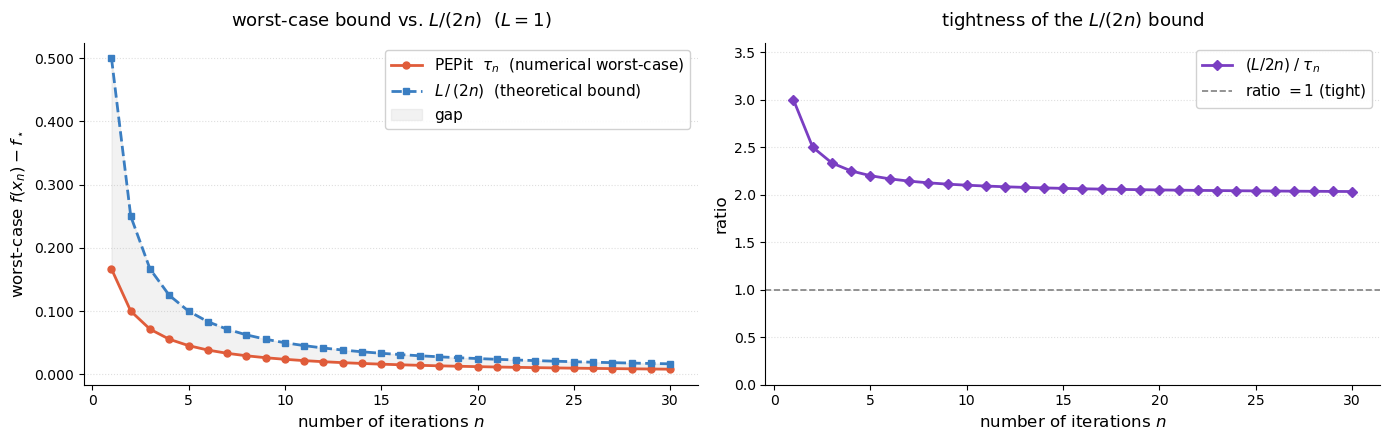

In [4]:
# --- run the comparison ---
L = 1
ns = np.arange(1, 31)

pepit_taus    = []
potential_taus = []
for i, n in enumerate(ns, 1):
    pt, lt = wc_gradient_descent(L=L, n=int(n), verbose=0)
    pepit_taus.append(pt)
    potential_taus.append(lt)
    print(f'{i} / {len(ns)} grid points computed', end='\r', flush=True)
print("done!                          ")

pepit_taus    = np.array(pepit_taus)
potential_taus = np.array(potential_taus)
ratio         = potential_taus / pepit_taus

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# -- left: raw curves --
ax = axes[0]
ax.plot(ns, pepit_taus,     color="#e05c3a", lw=2, marker="o", ms=5, label="PEPit  $\\tau_n$  (numerical worst-case)")
ax.plot(ns, potential_taus, color="#3a7ec2", lw=2, ls="--", marker="s", ms=5, label="$L\\,/\\,(2n)$  (theoretical bound)")
ax.fill_between(ns, pepit_taus, potential_taus, color="#aaaaaa", alpha=0.15, label="gap")
ax.set_xlabel("number of iterations $n$", fontsize=12)
ax.set_ylabel("worst-case $f(x_n) - f_\\star$", fontsize=12)
ax.set_title("worst-case bound vs. $L/(2n)$  $(L=1)$", fontsize=13, pad=12)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
ax.legend(framealpha=0.9, fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", ls=":", alpha=0.4)

# -- right: ratio --
ax = axes[1]
ax.plot(ns, ratio, color="#7a3ec2", lw=2, marker="D", ms=5, label="$(L/2n) \\;/\\; \\tau_n$")
ax.axhline(1.0, color="gray", lw=1.2, ls="--", label="ratio $= 1$ (tight)")
ax.set_xlabel("number of iterations $n$", fontsize=12)
ax.set_ylabel("ratio", fontsize=12)
ax.set_title("tightness of the $L/(2n)$ bound", fontsize=13, pad=12)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.set_ylim(0, max(ratio) * 1.2)
ax.legend(framealpha=0.9, fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", ls=":", alpha=0.4)

plt.tight_layout()
plt.savefig("gd_pepit_vs_bound.pdf", bbox_inches="tight")
plt.show()

As a conclusion, the potential function-based proof seems fairly accurate: it predicts the correct worst-case rate, and is only off by a constant factor of about $2$.

#### 1.2. Nesterov's accelerated gradient method (NAG)

Before moving to the next exercises (verifying and proving potential functions), let us first do a similar exercise for Nesterov's accelerated method, by considering the following algorithm instead of gradient descent:

$$
\begin{aligned}
y_{k}&=x_k+\tau_k (z_k-x_k)\\
x_{k+1}&=y_{k}-\alpha_k \nabla f(y_{k})\\
z_{k+1}&=z_k-\gamma_k \nabla f(y_{k}),
\end{aligned}
$$

where we can pick $\tau_k=1-A_k/A_{k+1}$, $\alpha_k=\frac{1}{L}$, and $\gamma_k=\frac{A_{k+1}-A_k}{L}$, together with $A_{k+1}=A_k+\frac{1}{2}(1+\sqrt{4 A_k+1})$. Then, the following theorem holds and provide a potential function of the form

$$ \phi_k = A_k (f(x_k)-f_\star) + \tfrac{L}{2} \|z_k-x_\star\|^2 $$

for NAG. As before, one can then recursively use $\phi_{k+1}\leq \phi_k$ to reach $f(x_n)-f_\star\leq \tfrac{L}{2 A_n} \|x_0-x_\star\|^2$ (when picking $A_0=0$) and properties of $A_n$ are driving convergence of the bound.

**Theorem (a potential function for Nesterov's method).** Let $f$ be an $L$-smooth convex function, $x_\star\in\mathrm{argmin}_x\, f(x)$, and $k\in\mathbb{N}$. For any $x_k,z_k\in\mathbb{R}^d$ and $A_k\geq 0$, the iterates of the algorithm above satisfy

$$A_{k+1}(f(x_{k+1})-f_\star)+\frac{L}{2}\|z_{k+1}-x_\star\|^2\leq A_k (f(x_k)-f_\star)+\frac{L}{2} \|z_k-x_\star\|^2,$$

with $A_{k+1}=A_{k}+\frac{1+\sqrt{4A_{k}+1}}{2}$.

In [5]:
# Full-PEP for Nesterov's
def wc_NAG(L, n, verbose=0):
    
    # Setup the stepsize
    gamma = 1/L
    
    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    f = problem.declare_function(SmoothConvexFunction, L=L)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Then define the starting point x0 of the algorithm
    x0 = problem.set_initial_point()

    # Set the initial constraint that is the distance between x0 and x^*
    problem.set_initial_condition((x0 - xs) ** 2 <= 1)

    # Run n steps of the GD method
    x = x0
    z = x0
    A_new = 0
    for _ in range(n):
        A_old = A_new
        A_new = A_old + ( 1 + np.sqrt(4*A_old + 1) )/2 
        y = x + (1-A_old/A_new) * (z - x)
        x = y - 1/L * f.gradient(y)
        z = z - (A_new-A_old)/L * f.gradient(y)

    # Set the performance metric to the function values accuracy
    problem.set_performance_metric(f(x) - fs)

    # Solve the PEP
    pepit_verbose = max(verbose, 0)
    pepit_tau = problem.solve(verbose=pepit_verbose)

    potential_tau = L/2/A_new
    # Return the worst-case guarantee of the evaluated method (and the reference theoretical value)
    return pepit_tau, potential_tau

done!                          


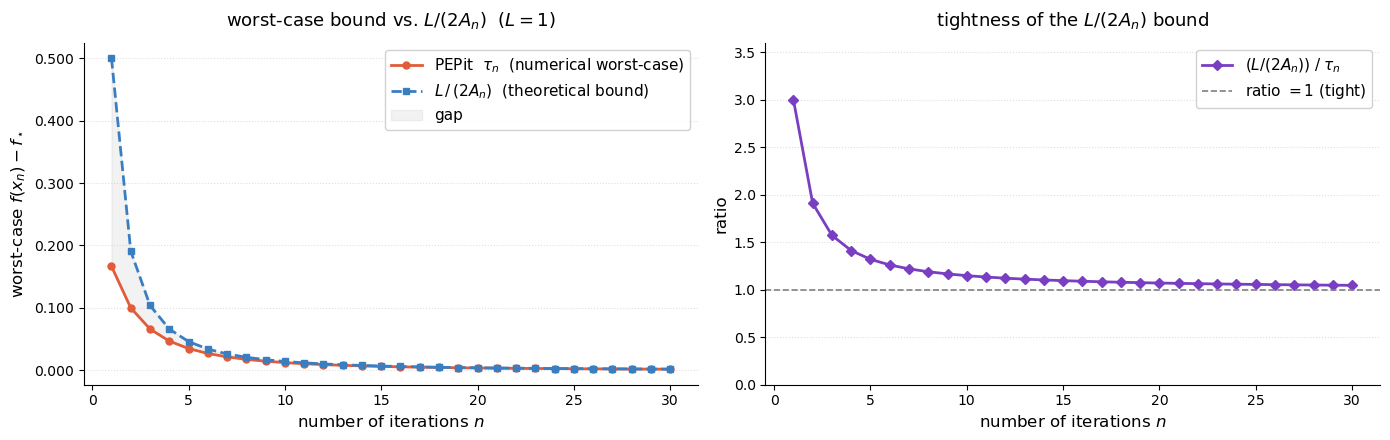

In [6]:
# --- run the comparison with FULL pep ---
L = 1
ns = np.arange(1, 31)

pepit_taus    = []
potential_taus = []
for i, n in enumerate(ns, 1):
    pt, lt = wc_NAG(L=L, n=int(n), verbose=0)
    pepit_taus.append(pt)
    potential_taus.append(lt)
    print(f'{i} / {len(ns)} grid points computed', end='\r', flush=True)
print("done!                          ")

pepit_taus    = np.array(pepit_taus)
potential_taus = np.array(potential_taus)
ratio         = potential_taus / pepit_taus

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# -- left: raw curves --
ax = axes[0]
ax.plot(ns, pepit_taus,     color="#e05c3a", lw=2, marker="o", ms=5, label="PEPit  $\\tau_n$  (numerical worst-case)")
ax.plot(ns, potential_taus, color="#3a7ec2", lw=2, ls="--", marker="s", ms=5, label="$L\\,/\\,(2A_n)$  (theoretical bound)")
ax.fill_between(ns, pepit_taus, potential_taus, color="#aaaaaa", alpha=0.15, label="gap")
ax.set_xlabel("number of iterations $n$", fontsize=12)
ax.set_ylabel("worst-case $f(x_n) - f_\\star$", fontsize=12)
ax.set_title("worst-case bound vs. $L/(2A_n)$  $(L=1)$", fontsize=13, pad=12)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
ax.legend(framealpha=0.9, fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", ls=":", alpha=0.4)

# -- right: ratio --
ax = axes[1]
ax.plot(ns, ratio, color="#7a3ec2", lw=2, marker="D", ms=5, label="$(L/(2A_n)) \\;/\\; \\tau_n$")
ax.axhline(1.0, color="gray", lw=1.2, ls="--", label="ratio $= 1$ (tight)")
ax.set_xlabel("number of iterations $n$", fontsize=12)
ax.set_ylabel("ratio", fontsize=12)
ax.set_title("tightness of the $L/(2A_n)$ bound", fontsize=13, pad=12)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.set_ylim(0, max(ratio) * 1.2)
ax.legend(framealpha=0.9, fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", ls=":", alpha=0.4)

plt.tight_layout()
plt.savefig("nag_pepit_vs_bound.pdf", bbox_inches="tight")
plt.show()

As a conclusion, the potential function-based proof seems extremely accurate for NAG: it predicts the correct worst-case rate, and is only off by a constant factor that appears to tend to $1$.

A natural question is therefore: how do we obtain the corresponding proofs?

### 2. Proving classical Lyapunov/potential inequalities <a class="anchor" id="sec2"></a>

In what follows, we still consider the question of *verifying* certain potential/Lyapunov-based proofs. The first step consists in casting such problems as small-sized performance estimation ones.

We proceed in four stages:

1. we can those problems within PEPit.
2. We redo the modeling steps directly directly within CVXPY, as it will allow us to have a bit more degrees of freedom in our choices (and also to simply learn the process).
3. We transform our *primal semidefinite problem* (searching for worst-case functions) to a dual one.
4. We use our degrees of freedom to come up with *simple* proofs for the two methods above (and FISTA).

#### 2.1. Verifying gradient descent's potential with PEPit

For this first question, let us mention that there are actually quite a few ways to proceed. For instance:

1. as our goal is to verify $\phi_{k+1}\leq \phi_k$ (given $A_k$, and for all *initial* states $x_k$ and for all function $f$ satisfying our assumptions), one can simply verify that 

$$ 0 \geq \max_{f,x_k,x_{k+1},x_\star} \left\{\phi_{k+1}-\phi_k\,\,\text{s.t. }\, x_{k+1}=x_k-\tfrac1L \nabla f(x_k),\, \nabla f(x_\star)=0\right\},$$

and hence one can simply code an usual performance estimation problem without an initial condition and whose objective is to maximize $\phi_{k+1}-\phi_k$.

2. Another perspective: our goal is to search for the largest possible $A_{k+1}$ such that the inequality $\phi_{k+1}\leq \phi_k$ is valid (with the same quantifiers as before). Hence, one can solve


$$  \max_{f,x_k,x_{k+1},x_\star} \left\{f(x_{k+1})-f_\star \,\,\text{s.t. }\, \phi_k-\tfrac{L}{2}\|x_{k+1}-x_\star\|^2\leq 1,\, x_{k+1}=x_k-\tfrac1L \nabla f(x_k),\, \nabla f(x_\star)=0\right\},$$

whose optimal value will be $1/A_{k+1}$ for the largest possible valid value of $A_{k+1}$.

The following code uses the second approach.

In [7]:
# Compute largest possible valid A_{k+1}
def potential_function_verif_GD(L, Ak, verbose=0):

    # Set the stepsize
    gamma = 1/L

    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    f = problem.declare_function(SmoothConvexFunction, L=L)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Then define the "starting point" xk of the algorithm as well as corresponding
    # gradient and function values gk and fk
    xk = problem.set_initial_point()
    gk, fk = f.oracle(xk)

    # Run the GD at iteration (k+1)
    xkp1 = xk - gamma * gk
    gkp1, fkp1 = f.oracle(xkp1)

    # Compute the Lyapunov function at iteration k
    init_lyapunov = Ak * (fk - fs) + L / 2 * (xk - xs) ** 2
    # PEP's initial condition
    init_condition = init_lyapunov - L / 2 * (xkp1 - xs) ** 2
    problem.set_initial_condition( init_condition <= 1)
    
    # Set the performance metric to function value accuracy at iteration k+1
    problem.set_performance_metric( fkp1 - fs )

    # Solve the PEP
    pepit_verbose = max(verbose, 0)
    pepit_tau = problem.solve(verbose=pepit_verbose)
    
    theoretical_Akp1 = Ak + 1
    pepit_max_Akp1 = 1/pepit_tau

    # Return the worst-case guarantee of the evaluated method (and the reference theoretical value)
    return pepit_max_Akp1, theoretical_Akp1

Plot the best provable $A_{k+1}$ as a function of $A_k$ for the case where $L=1$ and $\gamma=1/L$.

done!                          


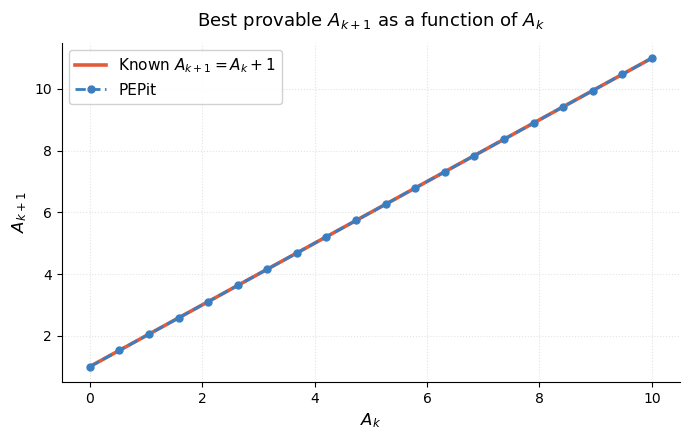

In [8]:
# --- run the comparison ---
L = 1
Ak_min = 0.
Ak_max = 10.
nb_Ak = 20
Ak_list = np.linspace(Ak_min, Ak_max, nb_Ak)

pepit_max_Akp1 = []
theoretical_Akp1 = []
for i, Ak in enumerate(Ak_list, 1):
    pt, lt = potential_function_verif_GD(L=L, Ak=Ak, verbose=0)
    pepit_max_Akp1.append(pt)
    theoretical_Akp1.append(lt)
    print(f'{i} / {len(Ak_list)} grid points computed', end='\r', flush=True)
print("done!                          ")

pepit_max_Akp1 = np.array(pepit_max_Akp1)
theoretical_Akp1 = np.array(theoretical_Akp1)

# --- plot ---
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(Ak_list, theoretical_Akp1, color="#e05c3a", lw=2.6, label=r"Known $A_{k+1}=A_k+1$")
ax.plot(Ak_list, pepit_max_Akp1, color="#3a7ec2", lw=2, ls="--", marker="o", ms=5, label="PEPit")
ax.set_xlabel(r"$A_k$", fontsize=12)
ax.set_ylabel(r"$A_{k+1}$", fontsize=12)
ax.set_title(r"Best provable $A_{k+1}$ as a function of $A_k$", fontsize=13, pad=12)
ax.grid(ls=":", alpha=0.35)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(framealpha=0.9, fontsize=11)

plt.tight_layout()
plt.savefig("Akp1_pepit_vs_bound.pdf", bbox_inches="tight")
plt.show()

Thus, it looks like one cannot expect to improve this simple potential-based without any twist (we will see a few possible ones at the end of the section).

#### 2.1. Primal problem

The goal of the next points is to constructively come up with (simple) proofs for those potentials. We start by re-coding a PEP from scratch using [CVXPY](https://www.cvxpy.org/) for coding the semidefinite programs.

In [9]:
### PARAMETERS OF PROBLEM & ALGORITHM
L = 1.
A0 = 10.
gamma = 1/L

### NOTATION: helper for the SDP representation
# WLOG: x_* = 0, f_* = 0
# P = [ x0 g0 g1]  ( recall that G = P^T P >> 0 )
# F = [    f0 f1]  

### PARAMETERS OF SDP
# Let us define a few parameters that we will need to use:
dimG  = 3   # Gram matrix dimension
dimF  = 2   # function-value vector length
nbPts = 3   # number of points in the discrete version of f (x*=0, x0, x1)

### HELPER: SELECTORS
# We define below helper vectors to pick the elements in G:
# those vectors allow to *pick* elements in P and F as follows:
# x_{k}  = P * xk  (i=0,1,*)
# g_{k}  = P * gk  (i=0,1,*)
# f_{k}  = F * fk  (i=0,1,*)
# This notation is convenient as it allows to also pick elements in G, as
# . <x_{i}; x_{j}> = xi^T * P^T * P * xj = xi^T * G * xj = Trace( G * xj*xi^T )
# . <g_{i}; g_{j}> = gi^T * P^T * P * gj = gi^T * G * gj = Trace( G * gj*gi^T )
# . <x_{i}; g_{j}> = xi^T * P^T * P * gj = xi^T * G * gj = Trace( G * gj*xi^T )
xs = np.zeros(dimG); 
x0 = np.zeros(dimG); x0[0] = 1;
gs = np.zeros(dimG); 
g0 = np.zeros(dimG); g0[1] = 1; 
g1 = np.zeros(dimG); g1[2] = 1; 

x1 = x0 - gamma * g0;

fs = np.zeros(dimF); 
f0 = np.zeros(dimF); f0[0] = 1; 
f1 = np.zeros(dimF); f1[1] = 1; 

### HELPER: LIST OF INTERPOLATED POINTS
# create the list of points to be interpolated
list_triplets_f = list() 
list_triplets_f.append((xs,gs,fs))
list_triplets_f.append((x0,g0,f0))
list_triplets_f.append((x1,g1,f1))


### MAIN SDP (primal form)
# Define variables
G = cp.Variable((dimG,dimG), symmetric=True)
constraints = [G >> 0] # G is PSD
F = cp.Variable(dimF)

# This is the initial condition:
constraints = constraints + [ A0 * (f0 - fs)@F + L/2 * (x0-xs)@G@(x0-xs) - L/2 * (x1-xs)@G@(x1-xs) <= 1]

# Loop over set of points to be interpolated: interpolation conditions
for i, triplet_i in enumerate(list_triplets_f):
    for j, triplet_j in enumerate(list_triplets_f):
        xi,gi,fi = triplet_i
        xj,gj,fj = triplet_j
        if i != j:
            # encode: 0 >= fj-fi + gj^T (xi-xj) + 1/2/L ||g_i-g_j||^2
            constraints = constraints + [ (fj-fi)@F + gj.T@G@(xi-xj) + 1/2/L * (gi-gj).T@G@(gi-gj) <= 0 ]

# Objective
obj = (f1 - fs)@F


### FORMULATE & SOLVE SDP
prob = cp.Problem(cp.Maximize(obj), constraints)
prob.solve()

[1/obj.value]

[np.float64(11.000020922293267)]

Verify that this code is in line with your previous PEPit implementation!

#### 2.2. Dual problem

Using minor notation twists, one can convert the previous primal problem into dual form. For this, let us recall that the following semidefinite problem

$$ \max_{G\succeq 0, F} \mathrm{Tr}(A_0 G) + \langle b_0; F\rangle \,\,\text{s.t. } \, \mathrm{Tr}(A_i G) + \langle b_i; F\rangle \leq c_i \,\, (i=1,\ldots,m)$$

has the following (standard) Lagrange dual (by associating $\lambda_i\geq 0$ to the constraint $\mathrm{Tr}(A_i G) + \langle b_i; F\rangle \leq c_i$):

$$ \min_{\lambda_i\geq 0} \langle \lambda; c\rangle \,\,\text{s.t. }\, -b_0+\sum_{i=1}^m\lambda_i b_i=0, S=-A_0+\sum_{i=1}^m\lambda_i A_i\succeq 0$$

**Warning.** We assumed $A_i$ to be symmetric for the dualization!

In [10]:
def solve_full_dual_gd(L, Ak, gamma=None, solver=None, verbose=False):
    if gamma is None:
        gamma = 1 / L

    dimG, dimF, nbPts = 3, 2, 3

    xs = np.zeros(dimG)
    x0 = np.zeros(dimG); x0[0] = 1
    gs = np.zeros(dimG)
    g0 = np.zeros(dimG); g0[1] = 1
    g1 = np.zeros(dimG); g1[2] = 1
    x1 = x0 - gamma * g0

    fs = np.zeros(dimF)
    f0 = np.zeros(dimF); f0[0] = 1
    f1 = np.zeros(dimF); f1[1] = 1

    list_triplets_f = [(xs, gs, fs), (x0, g0, f0), (x1, g1, f1)]

    S = cp.Variable((dimG, dimG), symmetric=True)
    lams = cp.Variable((nbPts, nbPts), symmetric=False)
    A1 = cp.Variable()

    constraints = [S >> 0, lams >= 0, cp.diag(lams) == 0]

    lin_cons = Ak * (f0 - fs) - A1 * (f1 - fs)
    lmi_cons = L / 2 * np.outer(x0 - xs, x0 - xs) - L / 2 * np.outer(x1 - xs, x1 - xs)

    for i, triplet_i in enumerate(list_triplets_f):
        for j, triplet_j in enumerate(list_triplets_f):
            if i == j:
                continue

            xi, gi, fi = triplet_i
            xj, gj, fj = triplet_j

            bij = fj - fi
            Aij = np.outer(gj, xi - xj) + 1 / (2 * L) * np.outer(gi - gj, gi - gj)
            Aij = 0.5 * (Aij + Aij.T)

            lin_cons = lin_cons + lams[i, j] * bij
            lmi_cons = lmi_cons + lams[i, j] * Aij

    constraints += [lin_cons == 0, lmi_cons == S]
    prob = cp.Problem(cp.Maximize(A1), constraints)

    solve_kwargs = {"verbose": verbose}
    if solver is not None:
        solve_kwargs["solver"] = solver
    prob.solve(**solve_kwargs)

    if A1.value is None or S.value is None or lams.value is None:
        raise RuntimeError(f"Dual solve failed with status {prob.status}.")

    S_val = np.array(S.value)
    lin_val = np.array(lin_cons.value).ravel()
    lmi_res = np.array(lmi_cons.value) - S_val
    min_eig_S = np.min(np.linalg.eigvalsh(0.5 * (S_val + S_val.T)))

    return {
        "status": prob.status,
        "A1": float(A1.value),
        "lams": np.array(lams.value),
        "lin_residual": float(np.max(np.abs(lin_val))),
        "lmi_residual": float(np.linalg.norm(lmi_res, ord="fro")),
        "min_eig_S": float(min_eig_S),
    }


### PARAMETERS OF PROBLEM & ALGORITHM
L = 1.
A0 = 10.
gamma = 1 / L

sol = solve_full_dual_gd(L=L, Ak=A0, gamma=gamma)
sol["A1"]

11.000859920444956

Plot dual variables as function of the rest + check residual!

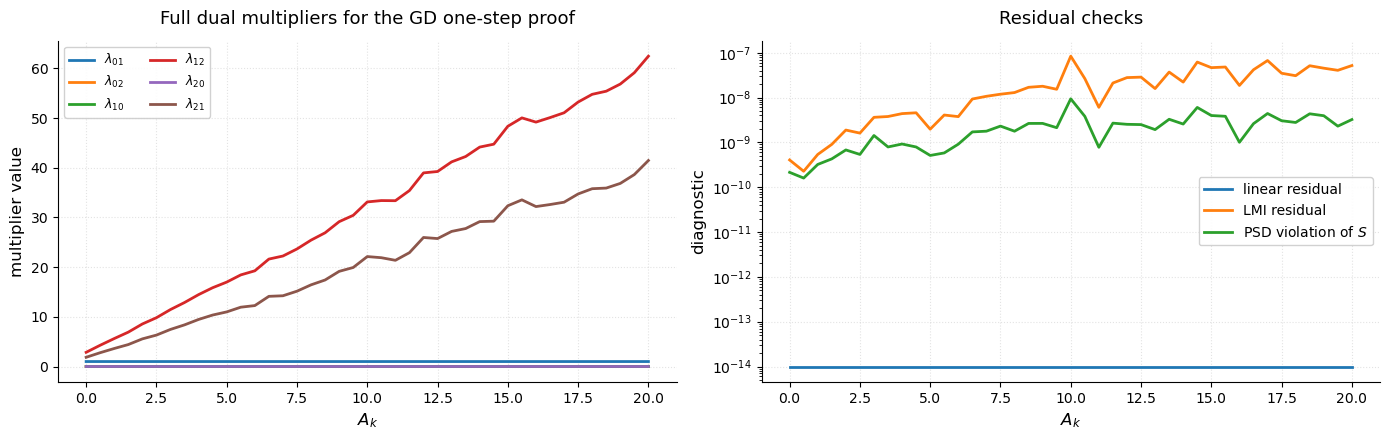

In [11]:
Ak_grid = np.linspace(0.0, 20.0, 41)
sols = [solve_full_dual_gd(L=1.0, Ak=Ak) for Ak in Ak_grid]
pairs = [(i, j) for i in range(3) for j in range(3) if i != j]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for i, j in pairs:
    axes[0].plot(
        Ak_grid,
        [sol["lams"][i, j] for sol in sols],
        lw=2,
        label=rf"$\lambda_{{{i}{j}}}$",
    )
axes[0].set_xlabel(r"$A_k$", fontsize=12)
axes[0].set_ylabel("multiplier value", fontsize=12)
axes[0].set_title("Full dual multipliers for the GD one-step proof", fontsize=13, pad=12)
axes[0].grid(ls=":", alpha=0.35)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].legend(ncol=2, fontsize=9, framealpha=0.9)

axes[1].semilogy(
    Ak_grid,
    np.maximum(1e-14, [sol["lin_residual"] for sol in sols]),
    lw=2,
    label="linear residual",
)
axes[1].semilogy(
    Ak_grid,
    np.maximum(1e-14, [sol["lmi_residual"] for sol in sols]),
    lw=2,
    label="LMI residual",
)
axes[1].semilogy(
    Ak_grid,
    np.maximum(1e-14, [max(0.0, -sol["min_eig_S"]) for sol in sols]),
    lw=2,
    label=r"PSD violation of $S$",
)
axes[1].set_xlabel(r"$A_k$", fontsize=12)
axes[1].set_ylabel("diagnostic", fontsize=12)
axes[1].set_title("Residual checks", fontsize=13, pad=12)
axes[1].grid(ls=":", alpha=0.35)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].legend(framealpha=0.9)

plt.tight_layout()
plt.show()

Numerically, the dual optimum matches the primal value found in the previous cell. The multiplier sweep also suggests that only a subset of the interpolation inequalities is active across the range of $A_k$ values considered here.

Before digging into the corresponding proof, let us try to bridge what we have with what is known. More precisely: known proofs for the potential function of gradient descent typically *do not* rely on interpolation inequalities. So let us try to simplify the proof so that it accounts for the classical inequalities instead of the interpolation ones (which is nice because the proof is simpler and can be used more generally).

##### 2.3. Numerical searching for smplified proofs

It is very well known that proving $f(x_k)-f_\star=O(1/k)$ for gradient descent does not require all those inequalities. Can you instead reproduce a proof that only relies on:

**A. Convexity** of $f$ between $x_k$ and $x_\star$:

$$
0 \geq f(x_k) - f_\star + \langle \nabla f(x_k),\, x_\star - x_k \rangle.
$$

**B. Smoothness** of $f$ between $x_k$ and $x_{k+1}$:

$$
0 \geq f(x_{k+1}) - \left( f(x_k) + \langle \nabla f(x_k),\, x_{k+1} - x_k \rangle + \frac{L}{2}\| x_k - x_{k+1}\|^2 \right).
$$

In [12]:
def solve_simplified_dual_gd(L, Ak, gamma=None, solver=None, verbose=False):
    if gamma is None:
        gamma = 1 / L

    dimG, dimF = 3, 2

    xs = np.zeros(dimG)
    x0 = np.zeros(dimG); x0[0] = 1
    gs = np.zeros(dimG)
    g0 = np.zeros(dimG); g0[1] = 1
    g1 = np.zeros(dimG); g1[2] = 1
    x1 = x0 - gamma * g0

    fs = np.zeros(dimF)
    f0 = np.zeros(dimF); f0[0] = 1
    f1 = np.zeros(dimF); f1[1] = 1

    list_triplets_f = [(xs, gs, fs), (x0, g0, f0), (x1, g1, f1)]

    S = cp.Variable((dimG, dimG), symmetric=True)
    lams = cp.Variable(2, nonneg=True)
    A1 = cp.Variable()

    constraints = [S >> 0]

    lin_cons = Ak * (f0 - fs) - A1 * (f1 - fs)
    lmi_cons = L / 2 * np.outer(x0 - xs, x0 - xs) - L / 2 * np.outer(x1 - xs, x1 - xs)

    # convexity between x_* and x_k
    xi, gi, fi = list_triplets_f[0]
    xj, gj, fj = list_triplets_f[1]
    bij = fj - fi
    Aij = np.outer(gj, xi - xj)
    Aij = 0.5 * (Aij + Aij.T)
    lin_cons = lin_cons + lams[0] * bij
    lmi_cons = lmi_cons + lams[0] * Aij

    # smoothness upper bound between x_k and x_{k+1}
    xi, gi, fi = list_triplets_f[1]
    xj, gj, fj = list_triplets_f[2]
    bij = fj - fi
    Aij = -(np.outer(gi, xj - xi) + L / 2 * np.outer(xi - xj, xi - xj))
    Aij = 0.5 * (Aij + Aij.T)
    lin_cons = lin_cons + lams[1] * bij
    lmi_cons = lmi_cons + lams[1] * Aij

    constraints += [lin_cons == 0, lmi_cons == S]
    prob = cp.Problem(cp.Maximize(A1), constraints)

    if solver is None:
        solver = cp.CLARABEL

    solve_kwargs = {"verbose": verbose, "solver": solver}
    prob.solve(**solve_kwargs)

    if A1.value is None or S.value is None or lams.value is None:
        raise RuntimeError(f"Simplified dual solve failed with status {prob.status}.")

    S_val = np.array(S.value)
    min_eig_S = np.min(np.linalg.eigvalsh(0.5 * (S_val + S_val.T)))

    return {
        "status": prob.status,
        "A1": float(A1.value),
        "lambda_1": float(lams.value[0]),
        "lambda_2": float(lams.value[1]),
        "lin_residual": float(np.max(np.abs(np.array(lin_cons.value).ravel()))),
        "min_eig_S": float(min_eig_S),
    }


### PARAMETERS OF PROBLEM & ALGORITHM
L = 1.
A0 = 10.
gamma = 1 / L

sol = solve_simplified_dual_gd(L=L, Ak=A0, gamma=gamma)
sol

{'status': 'optimal',
 'A1': 11.00000074609024,
 'lambda_1': 1.0000007460902411,
 'lambda_2': 11.00000074609024,
 'lin_residual': 0.0,
 'min_eig_S': -2.7602385705541114e-14}

Try to infer the closed-forms for those multipliers based on your numerical observations

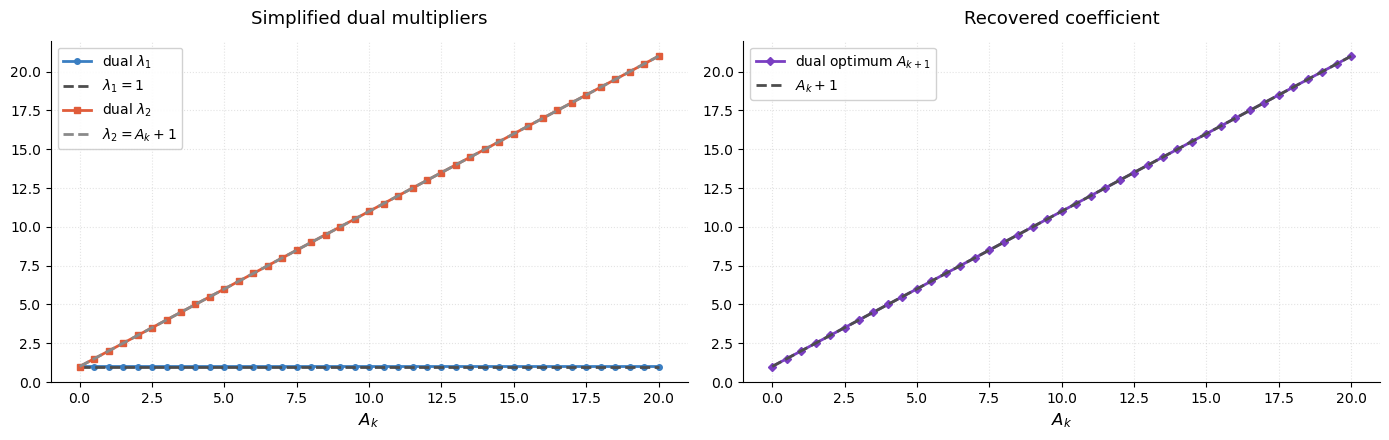

In [13]:
Ak_grid = np.linspace(0.0, 20.0, 41)
sols = [solve_simplified_dual_gd(L=1.0, Ak=Ak) for Ak in Ak_grid]

lam1 = np.array([sol["lambda_1"] for sol in sols])
lam2 = np.array([sol["lambda_2"] for sol in sols])
A1_vals = np.array([sol["A1"] for sol in sols])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(Ak_grid, lam1, color="#3a7ec2", lw=2, marker="o", ms=4, label=r"dual $\lambda_1$")
axes[0].plot(Ak_grid, np.ones_like(Ak_grid), color="#4d4d4d", ls="--", lw=2, label=r"$\lambda_1 = 1$")
axes[0].plot(Ak_grid, lam2, color="#e05c3a", lw=2, marker="s", ms=4, label=r"dual $\lambda_2$")
axes[0].plot(Ak_grid, Ak_grid + 1, color="#8a8a8a", ls="--", lw=2, label=r"$\lambda_2 = A_k + 1$")
axes[0].set_xlabel(r"$A_k$", fontsize=12)
axes[0].set_title("Simplified dual multipliers", fontsize=13, pad=12)
axes[0].grid(ls=":", alpha=0.35)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].legend(framealpha=0.9)

axes[1].plot(Ak_grid, A1_vals, color="#7a3ec2", lw=2, marker="D", ms=4, label=r"dual optimum $A_{k+1}$")
axes[1].plot(Ak_grid, Ak_grid + 1, color="#4d4d4d", ls="--", lw=2, label=r"$A_k + 1$")
axes[1].set_xlabel(r"$A_k$", fontsize=12)
axes[1].set_title("Recovered coefficient", fontsize=13, pad=12)
axes[1].grid(ls=":", alpha=0.35)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].legend(framealpha=0.9)

plt.tight_layout()
plt.show()

##### 2.4. From numerics to an actual proof

Come up with a proof using SymPy; can you get a general formula of the maximum value of $A_{k+1}$ as a function of $A_k$, $L$, and $\gamma$?

In [14]:
# create symbols for the problem parameters:
L = sm.Symbol('L')
mu = sm.Symbol('mu')
gamma = 1/L

# create symbols for the "primal" variables:
x0 = sm.Symbol('x0')
g0 = sm.Symbol('g0')
g1 = sm.Symbol('g1')
f0 = sm.Symbol('f0')
f1 = sm.Symbol('f1')
xs = 0 # wlog, x_* = 0
gs = 0 # constraint g_* = 0
fs = 0 # wlog, f_* = 0
x1 = x0 - gamma * g0 # define x1 using previous symbols:

# create symbols for the "dual" variables
A0 = sm.Symbol('A0')
A1 = sm.Symbol('A1')
l1 = sm.Symbol('lambda_1')
l2 = sm.Symbol('lambda_2')


# the two interpolation constraints in the form "constraint <= 0"
constraint1 = f0 - fs + g0*(xs-x0) 
constraint2 = f1 - (f0 + g0*(x1-x0) + L/2 * (x0-x1)**2)

# the objective and the "initial condition" constraint: (also in the form "constraint <= 0")
primal_objective = A1 * (f1-fs ) + L/2 * (x1-xs)**2
initial_condition = A0 * (f0-fs ) + L/2 * (x0-xs)**2

# Lagrangian:
Lagrangian = - l1*constraint1 - l2*constraint2 - initial_condition + primal_objective

# This is the LMI and linear constraints

LMI = sm.simplify(sm.hessian(-Lagrangian, (x0, g0, g1)) / 2)
vars_vec = sm.Matrix([f0, f1])
Linear = sm.Matrix([-Lagrangian]).jacobian(vars_vec)

LMI

Matrix([
[               0,     1/2 - lambda_1/2, 0],
[1/2 - lambda_1/2, (lambda_2 - 1)/(2*L), 0],
[               0,                    0, 0]])

In [15]:
Linear

Matrix([[A0 + lambda_1 - lambda_2, -A1 + lambda_2]])

#### Possible proof:

Now, it is very well known that GD does not require all those inequalities? Can you instead reproduce a proof that only relies on:

**A. Convexity** of $f$ between $x_k$ and $x_\star$, with weight $\lambda_1 = A_{k+1} - A_k$:

$$
0 \geq f(x_k) - f_\star + \langle \nabla f(x_k),\, x_\star - x_k \rangle.
$$

**B. Smoothness** of $f$ between $x_k$ and $x_{k+1}$, with weight $\lambda_2 = A_{k+1}$:

$$
0 \geq f(x_{k+1}) - \left( f(x_k) + \langle \nabla f(x_k),\, x_{k+1} - x_k \rangle + \frac{L}{2}\| x_k - x_{k+1}\|^2 \right).
$$
This second inequality is often called the **descent lemma**: substituting $x_{k+1}$ yields $f(x_{k+1}) \leq f(x_k) - \frac{1}{2L}\|\nabla f(x_k)\|^2$.

**Forming the weighted sum.** Combining both inequalities with their respective weights gives:

$$
0 \geq \lambda_1\bigl[f(x_k) - f_\star + \langle \nabla f(x_k),\, x_\star - x_k \rangle\bigr] + \lambda_2\bigl[f(x_{k+1}) - f(x_k) - \langle \nabla f(x_k),\, x_{k+1} - x_k \rangle - \tfrac{L}{2}\|x_k - x_{k+1}\|^2\bigr].
$$

*Substituting* $x_{k+1} = x_k - \tfrac{1}{L}\nabla f(x_k)$ and completing the square, this rewrites as:

$$
0 \geq (A_k+1)(f(x_{k+1})-f_\star)+\frac{L}{2}\|x_{k+1}-x_\star\|^2 - A_k(f(x_{k})-f_\star) - \frac{L}{2}\|x_{k}-x_\star\|^2 + \frac{A_{k+1}-1}{2L}\|\nabla f(x_k)\|^2 - (A_{k+1}-A_k-1)\langle \nabla f(x_k),\, x_k - x_\star \rangle.
$$

*Rearranging*, we obtain:

$$
\begin{align}
(A_k+1)&(f(x_{k+1})-f_\star)+\frac{L}{2}\|x_{k+1}-x_\star\|^2 \\
\leq\;& A_k(f(x_{k})-f_\star)+\frac{L}{2}\|x_{k}-x_\star\|^2 - \frac{A_{k+1}-1}{2L}\|\nabla f(x_k)\|^2 + (A_{k+1}-A_k-1)\langle \nabla f(x_k),\, x_k - x_\star \rangle \\
\leq\;& A_k(f(x_{k})-f_\star)+\frac{L}{2}\|x_{k}-x_\star\|^2,
\end{align}
$$

where the last step uses $A_{k+1} = A_k + 1$ (which zeros the inner-product term) and drops the residual $-\tfrac{A_k}{2L}\|\nabla f(x_k)\|^2 \leq 0$. $\blacksquare$

#### 2.5. A more general potential function

Adapt the previous steps to study the potential

$$ \phi_k = A_k (f(x_k)-f_\star) + \frac{B_k}{L}\|\nabla f(x_k)\|^2 + \frac{L}{2}\|x_k-x_\star\|^2.$$

For simplicity, set $A_{k+1}=A_k+1$ as before.

Explore numerically: 
- how can you pick $B_{k+1}$ as a function of $B_k,A_k$ so that $\phi_{k+1}\leq\phi_k$ remains valid?
- what can you conclude on the convergence rate of gradient descent in terms of the gradient norm residual?

In [16]:
# Compute largest possible valid B_{k+1}

from PEPit import PEP
from PEPit.functions import SmoothConvexFunction


def potential_GD_gradnorm(L, Ak, Bk, verbose=0):

    # Set the stepsize
    gamma = 1/L
    Akp1 = Ak + 1

    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    f = problem.declare_function(SmoothConvexFunction, L=L)

    # Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Then define the "starting point" xk of the algorithm as well as corresponding
    # gradient and function values gk and fk
    xk = problem.set_initial_point()
    gk, fk = f.oracle(xk)

    # Run the GD at iteration (k+1)
    xkp1 = xk - gamma * gk
    gkp1, fkp1 = f.oracle(xkp1)

    # Compute the Lyapunov function at iteration k
    init_lyapunov = Ak * (fk - fs) + Bk * gk**2 / L + L / 2 * (xk - xs) ** 2
    # PEP's initial condition
    init_condition = init_lyapunov - Akp1 * (fkp1 - fs) - L / 2 * (xkp1 - xs) ** 2
    problem.set_initial_condition( init_condition <= 1)
    
    # Set the performance metric to function value accuracy at iteration k+1
    problem.set_performance_metric( gkp1**2 / L)

    # Solve the PEP
    pepit_verbose = max(verbose, 0)
    pepit_tau = problem.solve(verbose=pepit_verbose)
    
    pepit_max_Bkp1 = 1/pepit_tau

    # Return the worst-case guarantee of the evaluated method (and the reference theoretical value)
    return pepit_max_Bkp1

Playing with the code, one can reasonably guess that we can: 

- set $A_{k+1}=A_k+1$
- set $B_{k+1}=B_k+A_{k+1}$. 

Thus, the choice $A_k=k$ and $B_k=\sum_{i=1}^{k+1} A_i=\frac{k(k+1)}{2}$. Hence, one can guess that $\|\nabla f(x_k)\|^2=O(k^{-2})$ for gradient descent.

In [17]:
L = 1
k = 10.
Ak, Bk = k, k*(k+1)/2
pepit_max_Bkp1 = potential_GD_gradnorm(L, Ak, Bk, verbose=0)

[pepit_max_Bkp1, Ak+1+Bk, (k+1)*(k+2)/2]

[65.99996679780774, 66.0, 66.0]

### 2.6. Nesterov's accelerated gradient method

Consider again Nesterov's method:
$$
\begin{aligned}
y_{k}&=x_k+\tau_k (z_k-x_k)\\
x_{k+1}&=y_{k}-\alpha_k \nabla f(y_{k})\\
z_{k+1}&=z_k-\gamma_k \nabla f(y_{k}),
\end{aligned}
$$
with $\tau_k=1-A_k/A_{k+1}$, $\alpha_k=\frac{1}{L}$, and $\gamma_k=\frac{A_{k+1}-A_k}{L}$, together with $A_{k+1}=A_k+\frac{1}{2}(1+\sqrt{4 A_k+1})$. A classical potential for Nesterov's algorithm is then

$$ \phi_k = A_k (f(x_k)-f_\star) + \tfrac{L}{2} \|z_k-x_\star\|^2.$$

In the following cells:
1. use PEPit in order to verify the potential function,
2. use PEPit in order check whether stronger properties could be obtained, for instance via the following potential

$$ \phi_k = A_k (f(x_k)-f_\star) + \tfrac{B_k}{2L} \|\nabla f(x_k)\|^2 + \tfrac{L}{2} \|z_k-x_\star\|^2.$$

What do you conclude on the convergence of NAG in terms of residual gradient norm?

In [18]:
# code
from PEPit import PEP
from PEPit.functions import SmoothConvexFunction


def potential_NAG(L, Ak, verbose=0):
    # Parameters
    Akp1 = Ak + (1 + np.sqrt(4 * Ak + 1)) / 2

    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    f = problem.declare_function(SmoothConvexFunction, L=L)

    # Define the optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Define the current iterate x_k and the anchor point z_k
    xk = problem.set_initial_point()
    zk = problem.set_initial_point()
    fxk = f(xk)

    # Run one NAG step
    yk = xk + (1 - Ak / Akp1) * (zk - xk)
    gyk = f.gradient(yk)
    xkp1 = yk - (1 / L) * gyk
    zkp1 = zk - ((Akp1 - Ak) / L) * gyk
    fxkp1 = f(xkp1)

    # Compute the Lyapunov function at iteration k and impose the initial condition
    init_lyapunov = Ak * (fxk - fs) + L / 2 * (zk - xs) ** 2
    problem.set_initial_condition(init_lyapunov - L / 2 * (zkp1 - xs) ** 2 <= 1)

    # Set the performance metric to the function value accuracy at iteration k+1
    problem.set_performance_metric(fxkp1 - fs)

    # Solve the PEP
    pepit_tau = problem.solve(verbose=max(verbose, 0))

    # Return the largest certified coefficient A_{k+1}
    return 1 / pepit_tau, Akp1


In [19]:
L = 1
Ak = 10

pepit_max_Akp1, Akp1 = potential_NAG(L, Ak, verbose=0)
[pepit_max_Akp1, Akp1]

[13.701599934916207, np.float64(13.701562118716424)]

In [20]:
# Compute the largest possible B_{k+1}:
# code
from PEPit import PEP
from PEPit.functions import SmoothConvexFunction


def potential_NAG_Bk(L, Ak, Bk, verbose=0):
    # Parameters
    Akp1 = Ak + (1 + np.sqrt(4 * Ak + 1)) / 2

    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    f = problem.declare_function(SmoothConvexFunction, L=L)

    # Define the optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Define the current iterate x_k and the anchor point z_k
    xk = problem.set_initial_point()
    zk = problem.set_initial_point()
    gxk, fxk = f.oracle(xk)

    # Run one NAG step
    yk = xk + (1 - Ak / Akp1) * (zk - xk)
    gyk = f.gradient(yk)
    xkp1 = yk - (1 / L) * gyk
    zkp1 = zk - ((Akp1 - Ak) / L) * gyk
    gxkp1, fxkp1 = f.oracle(xkp1)

    # Compute the Lyapunov function at iteration k and impose the initial condition
    init_lyapunov = Ak * (fxk - fs) + Bk * gxk ** 2 / (2 * L) + L / 2 * (zk - xs) ** 2
    init_condition = init_lyapunov - Akp1 * (fxkp1 - fs) - L / 2 * (zkp1 - xs) ** 2
    problem.set_initial_condition(init_condition <= 1)

    # Set the performance metric to the gradient term at iteration k+1
    problem.set_performance_metric(gxkp1 ** 2 / (2 * L))

    # Solve the PEP
    pepit_tau = problem.solve(verbose=max(verbose, 0))

    # Return the largest certified coefficient B_{k+1}
    return 1 / pepit_tau, Akp1


In [21]:
L = 1
Ak = 10.0
Bk = 0.0

pepit_max_Bkp1, Akp1 = potential_NAG_Bk(L, Ak, Bk, verbose=0)
{"max_valid_Bkp1": pepit_max_Bkp1, "Akp1": Akp1}


{'max_valid_Bkp1': 17.40312457657988, 'Akp1': np.float64(13.701562118716424)}

The previous cell starts from the original NAG potential (`B_k = 0`) and computes the largest valid coefficient in front of $\|\nabla f(x_{k+1})\|^2/(2L)$. It suggests that one can certify an even stronger gradient term than $A_{k+1}$. Verify numerically that the simpler certificate

$$ A_{k+1}(f(x_{k+1})-f_\star)+\tfrac{A_{k+1}}{2L}\|\nabla f(x_{k+1})\|^2+\tfrac{L}{2}\|z_{k+1}-x_\star\|^2\leq A_{k}(f(x_{k})-f_\star)+\tfrac{L}{2}\|z_{k}-x_\star\|^2.$$

What can you conclude on the *best (squared) gradient norm* observed accross the iterations $\min_{0\leq i\leq n} \|\nabla f(x_i)\|^2$ given that $A_k\geq \frac{k^2}{4}$? 


In [22]:
def Verify_NAG_potential_grads(L, Ak, verbose=0):
    # Parameters
    Akp1 = Ak + (1 + np.sqrt(4 * Ak + 1)) / 2

    # Instantiate PEP
    problem = PEP()

    # Declare a smooth convex function
    f = problem.declare_function(SmoothConvexFunction, L=L)

    # Define the optimal point xs = x_* and corresponding function value fs = f_*
    xs = f.stationary_point()
    fs = f(xs)

    # Define the current iterate x_k and the anchor point z_k
    xk = problem.set_initial_point()
    zk = problem.set_initial_point()
    fxk = f(xk)

    # Run one NAG step
    yk = xk + (1 - Ak / Akp1) * (zk - xk)
    gyk = f.gradient(yk)
    xkp1 = yk - (1 / L) * gyk
    zkp1 = zk - ((Akp1 - Ak) / L) * gyk
    gxkp1, fxkp1 = f.oracle(xkp1)

    # Compare the Lyapunov functions at iterations k and k+1
    init_lyapunov = Ak * (fxk - fs) + L / 2 * (zk - xs) ** 2
    fin_lyapunov = (
        Akp1 * (fxkp1 - fs)
        + Akp1 * gxkp1 ** 2 / (2 * L)
        + L / 2 * (zkp1 - xs) ** 2
    )

    # Set the performance metric to the Lyapunov difference
    problem.set_performance_metric(fin_lyapunov - init_lyapunov)

    # Solve the PEP
    pepit_tau = problem.solve(verbose=max(verbose, 0))
    return pepit_tau


In [23]:
L = 1
Ak_values = [0, 1, 5, 10]
[Verify_NAG_potential_grads(L, Ak) for Ak in Ak_values]

[0.0, 0.0, 0.0, 0.0]

To go further: one can proceed with similar steps as for gradient descent: 

1. simplify the set of inequalities to be used,
2. Verify that the obtained rate for the best gradient norm observed accross $n$ iterations indeed decrease as $O(n^{-3/2})$ for NAG.
3. use SymPy to get to a reasonable proof.

### 2.7. FISTA

Let us now consider FISTA [4] for composite convex minimization:
$$ \min_{x\in\mathbb{R}^d} \left\{F(x)\triangleq f(x)+h(x)\right\},$$

with $f$ being convex and $L$-smooth, and where $h$ is closed convex proper (ccp) with a proximal operator readily available. That is, we assume that one can easily compute:

$$ \mathrm{prox}_{\alpha h}(z)=\mathrm{argmin_{y}}\left(\alpha h(y)+\tfrac{1}{2}\|y-z\|^2\right),$$

where $\alpha>0$ is a stepsize.

FISTA is then given by:
$$
\begin{aligned}
y_{k}&=x_k+\left(1-\tfrac{A_k}{A_{k+1}}\right) (z_k-x_k)\\
x_{k+1}&=\mathrm{prox}_{h/L}\left(y_{k}-\alpha_k \nabla f(y_{k})\right)\\
z_{k+1}&=z_k+ (A_{k+1}-A_k) (x_{k+1}-y_k),
\end{aligned}
$$

The same Lyapunov structure extends naturally to the composite setting. For the Tseng/Beck--Teboulle form of FISTA used below, we verify numerically the potential

$$ A_k(F(x_k)-F_\star) + \tfrac{L}{2} \|z_k-x_\star\|^2.$$


In [24]:
# code
from PEPit import PEP
from PEPit.functions import SmoothConvexFunction
from PEPit.functions import ConvexFunction

from PEPit.primitive_steps import proximal_step


def potential_FISTA(L, Ak, verbose=0):
    # Parameters
    Akp1 = Ak + (1 + np.sqrt(4 * Ak + 1)) / 2

    # Instantiate PEP
    problem = PEP()

    # Declare the smooth and nonsmooth parts of the objective
    f = problem.declare_function(SmoothConvexFunction, L=L)
    h = problem.declare_function(ConvexFunction)
    F = f + h

    # Define the optimal point xs = x_* and corresponding function value fs = F_*
    xs = F.stationary_point()
    fs = F(xs)

    # Define the current iterate x_k and the anchor point z_k
    xk = problem.set_initial_point()
    zk = problem.set_initial_point()
    _, fxk = f.oracle(xk)
    _, hxk = h.oracle(xk)

    # Run one FISTA step
    yk = xk + (1 - Ak / Akp1) * (zk - xk)
    gyk = f.gradient(yk)
    xkp1, _, hxkp1 = proximal_step(yk - gyk / L, h, 1 / L)
    zkp1 = zk + (Akp1 - Ak) * (xkp1 - yk)
    _, fxkp1 = f.oracle(xkp1)

    Fxk = fxk + hxk
    Fxkp1 = fxkp1 + hxkp1

    # Compare the Lyapunov functions at iterations k and k+1
    init_lyapunov = Ak * (Fxk - fs) + L / 2 * (zk - xs) ** 2
    final_lyapunov = Akp1 * (Fxkp1 - fs) + L / 2 * (zkp1 - xs) ** 2

    # Set the performance metric to the Lyapunov difference
    problem.set_performance_metric(final_lyapunov - init_lyapunov)

    # Solve the PEP
    pepit_tau = problem.solve(verbose=max(verbose, 0))
    return pepit_tau


In [25]:
L = 1
Ak_values = [0, 1, 5, 10]
[potential_FISTA(L, Ak) for Ak in Ak_values]


[0.0, 0.0, 0.0, 0.0]

### 2.8. Going further: other algorithms

In the next sections, we further explore the realm of potential and Lyapunov function-proofs for the textbook first-order algorithms without more generalizations.

The interested reader can nevertheless explore other families of algorithms, such as:
- Proximal, forward-backward methods,
- randomized/stochastic methods,
- projection-free/Frank-Wolfe,
- online learning algorithms,
- methods that approximate the above,
- and many others.


### 3. A first approach to search potential functions  <a class="anchor" id="sec3"></a>

Reaching this point, the reader could be convinced that potential/Lyapunov-based proofs might prove useful. However, it remains quite unclear how to choose such proof structures. Should we guess what to put inside the potential? 
For gradient descent, the choices might seem relatively harmless, but the structure for the accelerated method requires being quite informed.

In this section, we examplify one approach to arrive to such potential functions constructively. As for that of the next section, the approach here heavily rely on the following observation: the linear matrix inequalities that we have met so far (a.k.a., dual PEPs) were *linear* in the parameters of the potential/Lyapunov function.

#### 3.1. Back to gradient descent and function values $f(x_n)-f(x_\star)$. 

Let us consider again gradient descent, and choose potential functions to have the following structure (which seems reasonable so far, since it contains all the *information* describing the state at iteration $k$):
$$
\phi_k=\begin{pmatrix}x_k-x_\star\\ \nabla f(x_k)\end{pmatrix}^\top \left[\begin{pmatrix}
a_k & c_k \\ c_k & b_k
\end{pmatrix}\otimes I_d\right]\begin{pmatrix}x_k-x_\star\\ \nabla f(x_k)\end{pmatrix} + d_k\, (f(x_k)-f(x_\star)),
$$

with $\phi_0=\frac{L}{2}\|x_0-x_\star\|^2$ and $\phi_n=d_n\, (f(x_n)-f(x_\star))$.

**Proof structure.** We will search for a sequence $\{\phi_i\}_{i=0,\ldots,n}$ such that $\phi_{k+1}\leq \phi_k$ with prescribed $\phi_0$ and $\phi_n$.

A motivation for this structure is that, together with its boundary conditions, leads to a guarantee of the form

$$f(x_n)-f(x_\star) \leq \frac{L\, \|x_0-x_\star\|^2}{2d_n}.$$

**Question.** What is the best achievable guarantee with such a Lyapunov-type proof? A natural way to try to answer this question consists in choosing  $\phi_i$'s by solving

$$\max_{\phi_1,\ldots,\phi_{n-1},\,d_n}\; d_n \quad \text{such that} \quad (\phi_0,\phi_1)\in\mathcal{V}_0,\;\ldots,\;(\phi_{T-1},\phi_T)\in\mathcal{V}_{n-1},$$

where $\mathcal{V}_i$ denotes the set of consecutive potentials such that $(\phi_i,\phi_{i+1})\in \mathcal{V}_i \Leftrightarrow \phi_i\leq \phi_{i+1}$ (with appropriate quantifiers).

**Code.** The code below implements the constraint $(\phi_i,\phi_{i+1})\in\mathcal{V}_i$. It uses the notation $Q_k\triangleq \begin{pmatrix}
a_k & c_k \\ c_k & b_k
\end{pmatrix}$ and $q_k=d_k$ for later convenience.

In [26]:
def Constraint_Lyapunov_Inequality(L,gamma,phi_k,phi_kp1):
    # phi_i is dictionnary containing matrix Qi and vector qi
    q0, Q0 = phi_k['q'], phi_k['Q']
    q1, Q1 = phi_kp1['q'], phi_kp1['Q']
    
    ### NOTATION: helper for the SDP representation
    # WLOG: x_* = 0, f_* = 0
    # P = [ x0 g0 g1]  ( recall that G = P^T P >> 0 )
    # F = [    f0 f1]  

    ### PARAMETERS OF SDP
    # Let us define a few parameters that we will need to use:
    dimG  = 3   # Gram matrix dimension
    dimF  = 2   # function-value vector length
    nbPts = 3   # number of points in the discrete version of f (x*=0, x0, x1)

    ### HELPER: SELECTORS
    # We define below helper vectors to pick the elements in G:
    # those vectors allow to *pick* elements in P and F as follows:
    # x_{k}  = P * xk  (i=0,1,*)
    # g_{k}  = P * gk  (i=0,1,*)
    # f_{k}  = F * fk  (i=0,1,*)
    # This notation is convenient as it allows to also pick elements in G, as
    # . <x_{i}; x_{j}> = xi^T * P^T * P * xj = xi^T * G * xj = Trace( G * xj*xi^T )
    # . <g_{i}; g_{j}> = gi^T * P^T * P * gj = gi^T * G * gj = Trace( G * gj*gi^T )
    # . <x_{i}; g_{j}> = xi^T * P^T * P * gj = xi^T * G * gj = Trace( G * gj*xi^T )
    xs = np.zeros(dimG); 
    x0 = np.zeros(dimG); x0[0] = 1;
    gs = np.zeros(dimG); 
    g0 = np.zeros(dimG); g0[1] = 1; 
    g1 = np.zeros(dimG); g1[2] = 1; 

    x1 = x0 - gamma * g0;

    fs = np.zeros(dimF); 
    f0 = np.zeros(dimF); f0[0] = 1; 
    f1 = np.zeros(dimF); f1[1] = 1; 

    ### HELPER: LIST OF INTERPOLATED POINTS
    # create the list of points to be interpolated
    list_triplets_f = list() 
    list_triplets_f.append((xs,gs,fs))
    list_triplets_f.append((x0,g0,f0))
    list_triplets_f.append((x1,g1,f1))


    ### SDP (dual form)
    S = cp.Variable((dimG,dimG), symmetric=True)
    constraints = [S >> 0]
    lams = cp.Variable((nbPts,nbPts), symmetric=False)
    constraints = constraints + [ lams >= 0]

    # This is the initial condition:
    lin_cons = q0 * (f0 - fs) - q1 * (f1 - fs)

    lyapunov_states_0 = np.concatenate([[x0-xs],[g0]])
    lyapunov_states_1 = np.concatenate([[x1-xs],[g1]])
    lmi_cons = lyapunov_states_0.T @ Q0 @ lyapunov_states_0 - lyapunov_states_1.T @ Q1 @ lyapunov_states_1

    # Loop over set of points to be interpolated: interpolation conditions
    for i, triplet_i in enumerate(list_triplets_f):
        for j, triplet_j in enumerate(list_triplets_f):
            xi,gi,fi = triplet_i
            xj,gj,fj = triplet_j
            if i != j:
                # encode: 0 >= fj-fi + gj^T (xi-xj) + 1/2/L ||g_i-g_j||^2
                bij = fj-fi
                Aij = np.outer(gj,xi-xj) + 1/2/L * np.outer(gi-gj,gi-gj)
                Aij = 1/2 * (Aij + Aij.T)
                lin_cons = lin_cons + lams[i,j] * bij
                lmi_cons = lmi_cons + lams[i,j] * Aij

    # Objective
    constraints = constraints + [lin_cons == 0]
    constraints = constraints + [lmi_cons == S]

    return constraints

Using this description of the set $\mathcal{V}_i$, complete the following lines to search for the sequence of potentials $phi_1,\ldots, phi_{n-1}$ maximizing $d_n$. What value of $d_n$ do you obtain for gradient descent with stepsize $1/L$?

In [27]:
# Time horizon
n = 20
stepsize = 1/L

# Fix
A0 = 0
B0 = 0
An = cp.Variable()
Bn = 0
constraints = []

phi_0 = dict()
phi_0['q'] = A0
phi_0['Q'] = np.array([[L/2,0],[0,B0/L]])

phi_n = dict()
phi_n['q'] = An
phi_n['Q'] = np.array([[0,0],[0,Bn/L]])

phi_k = list()
phi_k.append(phi_0)
for i in range(n):
    if i < n-1:
        phi_i = dict()
        phi_i['q'] = cp.Variable()
        phi_i['Q'] = cp.Variable((2,2),symmetric=True)
    else:
        phi_i = phi_n
    cons = Constraint_Lyapunov_Inequality(L,stepsize,phi_k[i],phi_i)
    phi_k.append(phi_i)
    constraints = constraints + cons

prob = cp.Problem(cp.Maximize(An),constraints)
prob.solve()

41.00000135127568

Using the following plotting tools (from Claude!) and by modifying the previous code, try to come up with a simple potential with a similar guarantee as the optimal one.

*Hint: you can impose additional constraints on the coefficients of the potential to try to simplify it.*

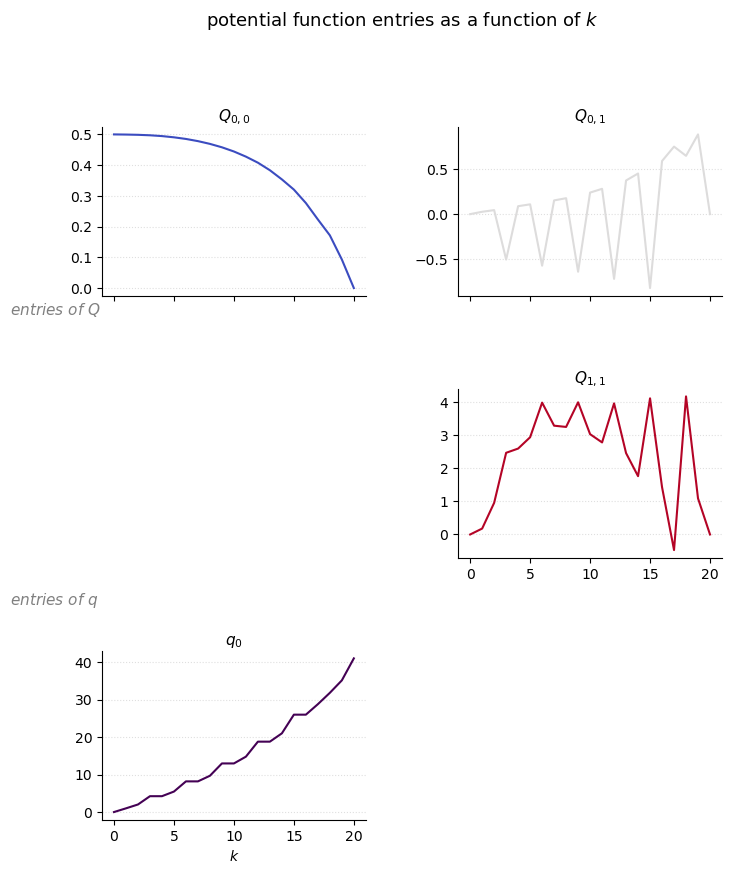

In [28]:
# This piece of code was generated by Claude.
# Usage below (for plotting the sequence of potential-function coefficients)

def extract_value(x):
    """safely extract a float from a cvxpy variable, numpy array, or scalar."""
    if hasattr(x, 'value'):
        v = x.value
        if v is None:
            return np.nan
        return float(np.array(v).flatten()[0])
    return float(np.array(x).flatten()[0])

def plot_phik(phi_k, N):
    t = np.arange(len(phi_k))

    # extract time series — safely unwrap cvxpy values
    Q_series = {(i, j): np.array([extract_value(phi_k[k]['Q'][i, j]) for k in t])
                for i in range(N + 1) for j in range(i, N + 1)}
    if N == 1:
        # q is a scalar (not a vector), handle separately
        q_series = {0: np.array([extract_value(phi_k[k]['q']) for k in t])}
    else:
        q_series = {i: np.array([extract_value(np.array(phi_k[k]['q']).flatten()[i]) for k in t])
                    for i in range(N)}

    # color palettes
    cmap_Q = plt.cm.coolwarm
    cmap_q = plt.cm.viridis
    n_Q    = len(Q_series)
    n_q    = N

    # --- layout ---
    fig = plt.figure(figsize=(4 * (N + 1), 3 * (N + 2)))
    gs  = gridspec.GridSpec(N + 2, N + 1, hspace=0.55, wspace=0.35, figure=fig)

    # -- Q subplots (upper triangle) --
    Q_axes = {}
    for idx, (i, j) in enumerate(Q_series):
        ax = fig.add_subplot(gs[i, j])
        color = cmap_Q(idx / max(n_Q - 1, 1))
        ax.plot(t, Q_series[(i, j)], color=color, lw=1.5)
        ax.set_title(f"$Q_{{{i},{j}}}$", fontsize=11, pad=4)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", ls=":", alpha=0.4)
        if i < N:
            ax.set_xticklabels([])
        Q_axes[(i, j)] = ax
        if i != j:
            fig.add_subplot(gs[j, i]).set_visible(False)

    # -- q subplots (bottom row) --
    for i in range(N):
        ax = fig.add_subplot(gs[N + 1, i])
        color = cmap_q(i / max(n_q - 1, 1))
        ax.plot(t, q_series[i], color=color, lw=1.5)
        ax.set_title(f"$q_{{{i}}}$", fontsize=11, pad=4)
        ax.set_xlabel("$k$", fontsize=10)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", ls=":", alpha=0.4)

    # hide unused cells in the q row
    for col in range(N, N + 1):
        fig.add_subplot(gs[N + 1, col]).set_visible(False)

    fig.text(0.01, (1 / (N + 2)) + 0.01, "entries of $q$",
             va="bottom", ha="left", fontsize=11, color="gray", style="italic")
    fig.text(0.01, (2 / (N + 2)), "entries of $Q$",
             va="bottom", ha="left", fontsize=11, color="gray", style="italic")
    fig.suptitle("potential function entries as a function of $k$",
                 fontsize=13, y=1.01)
    plt.savefig("Vt_entries.pdf", bbox_inches="tight")
    plt.show()

# --- usage ---
plot_phik(phi_k, N=1)

Modify your previous code to now search for a better convergence bound in term of (squared) gradient norm.
You can, for instance, start with $\phi_0=L^2\|x_0-x_\star\|^2$ and $\phi_n=b_n \|\nabla f(x_n)\|^2$.

- From your numerical experiments, what is the best bound on $\|\nabla f(x_n)\|^2$ that you could hope to achieve with such potential-function proofs?
- By simplifying the potential (and imposing additional constraints on the weights), can you get matching bounds (in terms of rates)?

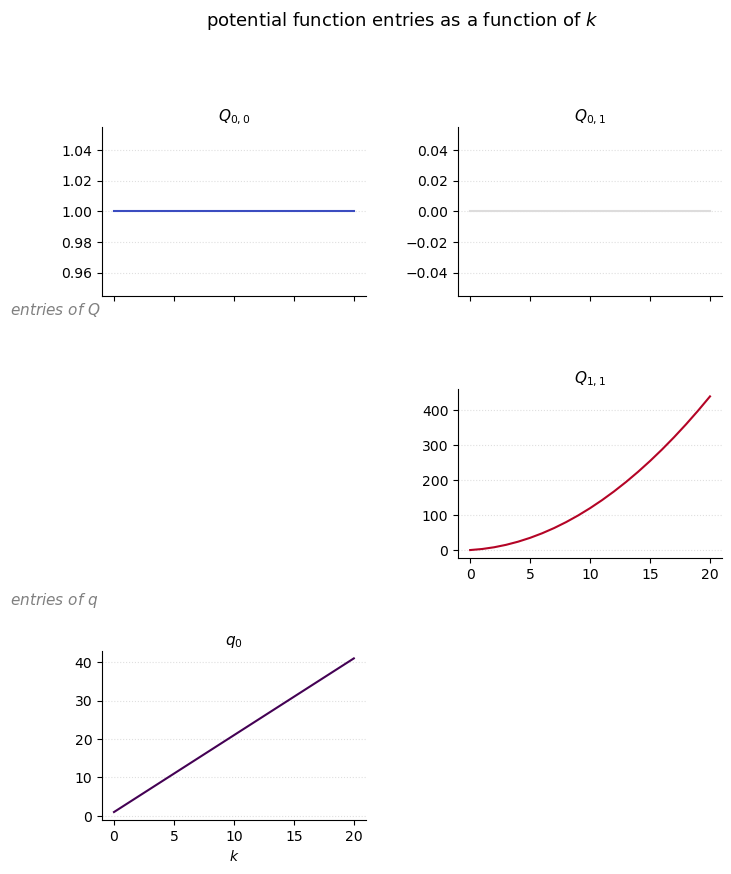

In [29]:
# Time horizon
n = 20

# Fix
A0 = 1
B0 = 0
An = 2*n+1
constraints = []

phi_0 = dict()
phi_0['q'] = A0
phi_0['Q'] = np.array([[L,0],[0,B0/L]])

phi_n = dict()
phi_n['q'] = An
phi_n['Q'] = cp.Variable((2,2), symmetric=True)

phi_k = list()
phi_k.append(phi_0)
for i in range(n):
    if i < n-1:
        phi_i = dict()
        phi_i['q'] = cp.Variable()
        phi_i['Q'] = cp.Variable((2,2),symmetric=True)
        constraints = constraints + [phi_i['Q'][0,0] == L]
        constraints = constraints + [phi_i['Q'][0,1] == 0]
        constraints = constraints + [phi_i['q'] == 2*(i+1)+1]
    else:
        phi_i = phi_n
    cons = Constraint_Lyapunov_Inequality(L,stepsize,phi_k[i],phi_i)
    phi_k.append(phi_i)
    constraints = constraints + cons

constraints = constraints + [phi_n['Q'][0,1] == 0]
constraints = constraints + [phi_n['Q'][0,0] == L]
Bn = phi_n['Q'][1,1]/L
prob = cp.Problem(cp.Maximize(Bn),constraints)
prob.solve()

plot_phik(phi_k, N=1)

### 4. Searching for Lyapunov inequalities certifying linear (exponential) convergence  <a class="anchor" id="sec4"></a>

This section show how specifically exploits the case where the algorithm might exhibit *linear* (or exponential) convergence on a class of problems. This is typically what happens when minimizing *smooth strongly convex functions*. In this section, we focus on this case, and denote by $f\in\mathcal{F}_{\mu,L}$ an $L$-smooth $\mu$-strongly convex function. We denote by $\kappa\triangleq \tfrac{L}{\mu}$ the corresponding condition ratio.

**What is a Lyapunov function?** Lyapunov functions are among the fundamental tools for verifying the stability of a dynamical system. For our purposes, consider a sequence $\xi_1, \xi_2, \ldots \in\mathbb{R}^m$ A Lyapunov function certifying a linear rate $\rho>0$ (hopefully $\rho\in (0,1)$) for this sequence is a continuous function $V:\mathbb{R}^m \rightarrow \mathbb{R}$ satisfying the following properties:

1. *(decreasing)* $V(\xi_{k+1})\leq\rho\,V(\xi_k)$ for all $k$,
2. *(lower bound)* there is a function $\nu(\cdot)$ such that $\nu(\xi-\xi_\star)\leq V(\xi)$.
3. *(zero at fixed point)* $V(\xi)=0$ if and only if $\xi=\xi_\star$,

An additional classical requirement is that $V(\xi)\geq 0$ for all $\xi$ *(nonnegativity)*. For us, it will be implied by the second condition (lower bound), which we will choose meaningfully. For instance, one could search for Lyapunov functions with $\nu(\xi-\xi_\star)=\|\xi-\xi_\star\|^2$. In this case, any function $V(\cdot)$ satisfying 1--3 would allow concluding that:

$$\|\xi_n-\xi_\star\|^2=\nu(\xi_n-\xi_\star)\leq V(\xi_n)\leq \rho V(\xi_{n-1})\leq \ldots\leq \rho^{n} V(\xi_0),$$

and hence linear convergence of $\xi_n$ towards $\xi_\star$.
#### 4.1. Gradient descent


For gradient descent, we naturally choose the *state* of the Lyapunov function similar to as in the previous case, as

$$\xi_k=\begin{pmatrix}x_k-x_\star\\\nabla f(x_k)\\f(x_k)-f_\star\end{pmatrix}$$

and a candidate Lyapunov function of the form (it remains to choose a symmetric $P\in\mathbb{S}^{2}$ and $p\in\mathbb{R}$)

$$V(\xi_k)=\begin{pmatrix}x_k-x_\star\\\nabla f(x_k)\end{pmatrix}^\top (P\otimes I_d)\begin{pmatrix}x_k-x_\star\\\nabla f(x_k)\end{pmatrix}+p^\top(f(x_k)-f_\star).$$

We also explicitly choose a lower bound of the form $\nu(\xi-\xi_\star)=\|x_k-x_\star\|^2$, which allows chaining

$$\|x_n-x_\star\|^2=\nu(\xi_n-\xi_\star)\leq V(\xi_n)\leq \rho V(\xi_{n-1})\leq \ldots\leq \rho^{n} V(\xi_0),$$

hence showing linear (exponential) convergence for $\|x_n-x_\star\|^2$. With this motivation in mind, we can search for a Lyapunov function by solving

$$\min_{(P,p)\in\mathcal{V}}\left\{\max_{\substack{d\in\mathbb{N},\, f\in\mathcal{F}_{\mu,L}\\ x_k,x_{k+1},x_\star\in\mathbb{R}^d}} \frac{V(\xi_{k+1})}{V(\xi_k)}:\, x_{k+1}=x_k-\tfrac{1}{L}\nabla f(x_k),\,\nabla f(x_\star)=0\right\},$$

where $\mathcal{V}$ denotes the set of $(P,p)\in\mathbb{S}^2\times\mathbb{R}$ such that $V(\xi)\geq \|x-x_\star\|^2$ for all $d\in\mathbb{N}$, $f\in\mathcal{F}_{\mu,L}$, and $\xi\in(\mathbb{R}^d)^2\times\mathbb{R}$ with $\nabla f(x_\star)=0$.

The inner maximization problem can be formulated as a standard semidefinite program using the same steps as before, as if the Lyapunov parameters $(P,p)$ were fixed. Those same steps also allow to accurately describe the set $\mathcal{V}$. Overall, given $\rho$, coupling the two descriptions allows to formulate the problem of verifying the existence of a Lyapunov function (certifying a convergence rate $\rho$) as a convex feasibility problem — this is due to the nice property that both reformulations are linear in $(P,p)$. Finding the best $\rho\geq 0$ certifiable through such a Lyapunov function then corresponds to a quasi-convex problem, which can be solved by bisecting over $\rho$.

**Positive definite quadratic Lyapunov functions for gradient descent.** A convenient classical choice is $P\succ 0$ and $p>0$, which easily meets the nonnegativity, zero at fixed point, and lower bound properties. For our purposes, we go slightly further: verifying the lower bound and nonnegativity (i.e., checking that a candidate belongs to $\mathcal{V}$) amounts to checking that for any $\epsilon>0$:

$$\epsilon \leq \inf_{\substack{d\in\mathbb{N},\,f\in\mathcal{F}_{\mu,L}\\ x,x_\star\in\mathbb{R}^d,\,\nabla f(x_\star)=0}} V\!\left([x-x_\star,\nabla f(x), f(x)-f_\star]\right) \quad \text{s.t. } \|x-x_\star\|^2 \geq \epsilon.$$

Using our now-classical reformulation tools (as in PEPs: sample, interpolate, and lift to an SDP), this condition can be shown to be equivalent to requiring that $V(\xi)$ can be written as a positive semidefinite part with $Q\succeq \begin{pmatrix}1&0\\0&0\end{pmatrix}$ and $q\geq 0$, plus a sum of non-negative terms from interpolation inequalities between $x$ and $x_\star$:

$$\begin{aligned}
V(\xi)=\,&\begin{pmatrix}x-x_\star\\\nabla f(x)\end{pmatrix}^\top (Q\otimes I_d)\begin{pmatrix}x-x_\star\\\nabla f(x)\end{pmatrix}+q^\top(f(x)-f_\star)\\
&+\lambda_1\left[f_\star-f(x)-\langle \nabla f(x),\,x_\star-x\rangle-\frac{1}{2L}\|\nabla f(x)\|^2-\frac{\mu}{2(1-\mu/L)}\|x-x_\star-\tfrac{1}{L}\nabla f(x)\|^2\right]\\
&+\lambda_2\left[f(x)-f_\star-\frac{1}{2L}\|\nabla f(x)\|^2-\frac{\mu}{2(1-\mu/L)}\|x-x_\star-\tfrac{1}{L}\nabla f(x)\|^2\right],
\end{aligned}$$

for some $\lambda_1, \lambda_2\geq 0$. Note that this expression is in terms of new parameters $(Q,q)$ (compared to $(P,p)$ above). The same structure appears across all first-order optimization settings we are aware of: a quadratic Lyapunov function always consists of a positive semidefinite part plus a sum of non-negative consequences of interpolation conditions evaluated at the states of the Lyapunov function.

**Searching for Lyapunov functions.** Now that we have characterized a family of candidate Lyapunov functions satisfying the nonnegativity, zero at fixed point, and lower bound properties, it remains to find parameters satisfying the decreasing property — hopefully for the smallest possible $\rho>0$. We formulate a feasibility problem involving two LMIs and a set of linear constraints:

- the first LMI encodes the nonnegativity, zero at fixed point, and lower bound properties: it imposes that $V(\cdot)$ is as above, with $Q\succeq \begin{pmatrix}1&0\\0&0\end{pmatrix}$, $q\geq 0$, and $\lambda_i\geq 0$.

- the second LMI forces that

$$0 \geq \sup_{\substack{d\in\mathbb{N},\,f\in\mathcal{F}_{\mu,L}\\ x_k,x_{k+1},x_\star\in\mathbb{R}^d}} V\!\left([x_{k+1}-x_\star,\nabla f(x_{k+1}), f(x_{k+1})-f_\star]\right)-\rho\, V\!\left([x_k-x_\star,\nabla f(x_k), f(x_k)-f_\star]\right)$$

$$\text{s.t. } x_{k+1}=x_k-\tfrac{1}{L}\nabla f(x_k).$$

Searching for the best (smallest) $\rho$ is then done via binary search: for each $\rho$, verifying the existence of a valid Lyapunov function certifying that rate reduces to solving the feasibility problem above.


In [30]:
def Verify_rho_GD(rho, gamma, L, mu, Qlower, qlower, verbose = False):
    
    ### NOTATION: helper for the SDP representation
    # WLOG: x_* = 0, f_* = 0
    # P = [ x0 g0 g1]  ( recall that G = P^T P >> 0 )
    # F = [    f0 f1]  

    ### PARAMETERS OF SDP
    # Let us define a few parameters that we will need to use:
    dimG  = 3   # Gram matrix dimension
    dimF  = 2   # function-value vector length
    nbPts = 3   # number of points in the discrete version of f (x*=0, x0, x1)
    dimGLyap = 2# (xk, gk) are the G-states of the Lyapunov function for GD
    dimFLyap = 1# (fk) is the F-state of the Lyapunov function for GD
    nbPtsLyap = 2   # number of points in the states of the Lyapunov: xk, x*
    
    xs = np.zeros(dimG); 
    x0 = np.zeros(dimG); x0[0] = 1;
    gs = np.zeros(dimG); 
    g0 = np.zeros(dimG); g0[1] = 1; 
    g1 = np.zeros(dimG); g1[2] = 1; 

    x1 = x0 - gamma * g0;

    fs = np.zeros(dimF); 
    f0 = np.zeros(dimF); f0[0] = 1; 
    f1 = np.zeros(dimF); f1[1] = 1; 

    ### HELPER: LIST OF INTERPOLATED POINTS
    # create the list of points to be interpolated
    list_triplets_f = list() 
    list_triplets_f.append((xs,gs,fs))
    list_triplets_f.append((x0,g0,f0))
    list_triplets_f.append((x1,g1,f1))
    
    ### SAME STORY: HELPER FOR LYAPUNOV
    xs_Lyap = np.zeros(dimGLyap); 
    x0_Lyap = np.zeros(dimGLyap); x0_Lyap[0] = 1;
    gs_Lyap = np.zeros(dimGLyap); 
    g0_Lyap = np.zeros(dimGLyap); g0_Lyap[1] = 1; 
    fs_Lyap = np.zeros(dimFLyap); 
    f0_Lyap = np.zeros(dimFLyap); f0_Lyap[0] = 1;

    ### HELPER: LIST OF INTERPOLATED POINTS
    # create the list of points to be interpolated
    list_triplets_Lyap = list() 
    list_triplets_Lyap.append((xs_Lyap,gs_Lyap,fs_Lyap))
    list_triplets_Lyap.append((x0_Lyap,g0_Lyap,f0_Lyap))

    ### Lyapunov variables
    Q = cp.Variable((dimGLyap, dimGLyap), symmetric=True)
    q = cp.Variable((dimFLyap))
    constraints = [ Q >> Qlower ]
    constraints = constraints + [ q >= qlower ]
    lams_Lyap = cp.Variable((nbPtsLyap,nbPtsLyap), symmetric=False)
    constraints = constraints + [ lams_Lyap >= 0 ]
    
    P = Q
    p = q
    for i, triplet_i in enumerate(list_triplets_Lyap):
        for j, triplet_j in enumerate(list_triplets_Lyap):
            xi,gi,fi = triplet_i
            xj,gj,fj = triplet_j
            if i != j:
                # encode: 0 >= fj-fi + gj^T (xi-xj) + 1/2/L ||g_i-g_j||^2
                bij = fj-fi
                Aij = np.outer(gj,xi-xj) + 1/2/L * np.outer(gi-gj,gi-gj) + mu/2/(1-mu/L) * np.outer(xi-xj-1/L*(gi-gj),xi-xj-1/L*(gi-gj))
                Aij = 1/2 * (Aij + Aij.T)
                p = p + lams_Lyap[i,j] * bij
                P = P + lams_Lyap[i,j] * Aij
    
    
    ### SDP (dual form)
    S = cp.Variable((dimG,dimG), symmetric=True)
    constraints = constraints + [S >> 0]
    lams = cp.Variable((nbPts,nbPts), symmetric=False)
    constraints = constraints + [ lams >= 0]

    # This is the initial condition:
    lin_cons = rho * p * (f0 - fs) - p * (f1 - fs)

    lyapunov_states_0 = np.concatenate([[x0-xs],[g0]])
    lyapunov_states_1 = np.concatenate([[x1-xs],[g1]])
    lmi_cons = rho * lyapunov_states_0.T @ P @ lyapunov_states_0 - lyapunov_states_1.T @ P @ lyapunov_states_1

    # Loop over set of points to be interpolated: interpolation conditions
    for i, triplet_i in enumerate(list_triplets_f):
        for j, triplet_j in enumerate(list_triplets_f):
            xi,gi,fi = triplet_i
            xj,gj,fj = triplet_j
            if i != j:
                # encode: 0 >= fj-fi + gj^T (xi-xj) + 1/2/L ||g_i-g_j||^2
                bij = fj-fi
                Aij = np.outer(gj,xi-xj) + 1/2/L * np.outer(gi-gj,gi-gj) + mu/2/(1-mu/L) * np.outer(xi-xj-1/L*(gi-gj),xi-xj-1/L*(gi-gj))
                Aij = 1/2 * (Aij + Aij.T)
                lin_cons = lin_cons + lams[i,j] * bij
                lmi_cons = lmi_cons + lams[i,j] * Aij

    # Objective
    constraints = constraints + [lin_cons == 0]
    constraints = constraints + [lmi_cons == S]

    ### FORMULATE & SOLVE SDP
    prob = cp.Problem(cp.Minimize(0), constraints)
    prob.solve(verbose = verbose, solver = cp.CLARABEL) # worth setting solver = cp.CLARABEL or cp.MOSEK (but MOSEK perhaps not installed)
    return prob

def bisect(rho_low, rho_high, gamma, L, mu, Qlower, qlower, tol=1e-5, verbose = False):
    
    while abs(rho_high-rho_low) > tol:
        rho_test = (rho_high+rho_low)/2
        prob = Verify_rho_GD(rho_test, gamma, L, mu, Qlower, qlower, verbose = verbose)
        if prob.status not in ["infeasible"]:
            rho_high = rho_test
            if verbose:
                print('success, tested rho was: {}, interval is now:[{}, {}]'.format(rho_test,rho_low,rho_high))
        else:
            rho_low = rho_test
            if verbose:
                print('fail, tested rho was: {}, interval is now:[{}, {}]'.format(rho_test,rho_low,rho_high))
    
    return rho_high

In [31]:
L, mu = 1, .1
gamma = 1/L
Qlower = np.array([[1,0],[0,0]])
qlower = np.array([0])

rho = bisect(0., 1. , gamma, L, mu, Qlower, qlower)

[rho]

[0.8100051879882812]

#### 4.2. Approximate GD

Adapt the code to study the convergence property of an approximate gradient method instead. That is, at each iteration, we now use

$$ x_{k+1} = x_k - \gamma d_k,$$

with $d_k$ satisfying some relative error criterion $\|d_k-\nabla f(x_k)\|\leq \epsilon \|\nabla f(x_k)\|$. Can you identify a Lyapunov function and a corresponding rate for this setup?

In [32]:
def Verify_rho_inexact_GD(rho, gamma, L, mu, epsilon, Qlower, qlower, verbose = False):
    
    ### NOTATION: helper for the SDP representation
    # WLOG: x_* = 0, f_* = 0
    # P = [ x0 g0 g1]  ( recall that G = P^T P >> 0 )
    # F = [    f0 f1]  

    ### PARAMETERS OF SDP
    # Let us define a few parameters that we will need to use:
    dimG  = 4   # Gram matrix dimension
    dimF  = 2   # function-value vector length
    nbPts = 3   # number of points in the discrete version of f (x*=0, x0, x1)
    dimGLyap = 2# (xk, gk) are the G-states of the Lyapunov function for GD
    dimFLyap = 1# (fk) is the F-state of the Lyapunov function for GD
    nbPtsLyap = 2   # number of points in the states of the Lyapunov: xk, x*
    
    xs = np.zeros(dimG); 
    x0 = np.zeros(dimG); x0[0] = 1;
    gs = np.zeros(dimG); 
    g0 = np.zeros(dimG); g0[1] = 1; 
    g1 = np.zeros(dimG); g1[2] = 1; 
    d0 = np.zeros(dimG); d0[3] = 1; 

    x1 = x0 - gamma * d0;

    fs = np.zeros(dimF); 
    f0 = np.zeros(dimF); f0[0] = 1; 
    f1 = np.zeros(dimF); f1[1] = 1; 

    ### HELPER: LIST OF INTERPOLATED POINTS
    # create the list of points to be interpolated
    list_triplets_f = list() 
    list_triplets_f.append((xs,gs,fs))
    list_triplets_f.append((x0,g0,f0))
    list_triplets_f.append((x1,g1,f1))
    
    ### SAME STORY: HELPER FOR LYAPUNOV
    xs_Lyap = np.zeros(dimGLyap); 
    x0_Lyap = np.zeros(dimGLyap); x0_Lyap[0] = 1;
    gs_Lyap = np.zeros(dimGLyap); 
    g0_Lyap = np.zeros(dimGLyap); g0_Lyap[1] = 1; 
    fs_Lyap = np.zeros(dimFLyap); 
    f0_Lyap = np.zeros(dimFLyap); f0_Lyap[0] = 1;

    ### HELPER: LIST OF INTERPOLATED POINTS
    # create the list of points to be interpolated
    list_triplets_Lyap = list() 
    list_triplets_Lyap.append((xs_Lyap,gs_Lyap,fs_Lyap))
    list_triplets_Lyap.append((x0_Lyap,g0_Lyap,f0_Lyap))

    ### Lyapunov variables
    Q = cp.Variable((dimGLyap, dimGLyap), symmetric=True)
    q = cp.Variable((dimFLyap))
    constraints = [ Q >> Qlower ]
    constraints = constraints + [ q >= qlower ]
    lams_Lyap = cp.Variable((nbPtsLyap,nbPtsLyap), symmetric=False)
    constraints = constraints + [ lams_Lyap >= 0 ]
    
    P = Q
    p = q
    for i, triplet_i in enumerate(list_triplets_Lyap):
        for j, triplet_j in enumerate(list_triplets_Lyap):
            xi,gi,fi = triplet_i
            xj,gj,fj = triplet_j
            if i != j:
                # encode: 0 >= fj-fi + gj^T (xi-xj) + 1/2/L ||g_i-g_j||^2
                bij = fj-fi
                Aij = np.outer(gj,xi-xj) + 1/2/L * np.outer(gi-gj,gi-gj) + mu/2/(1-mu/L) * np.outer(xi-xj-1/L*(gi-gj),xi-xj-1/L*(gi-gj))
                Aij = 1/2 * (Aij + Aij.T)
                p = p + lams_Lyap[i,j] * bij
                P = P + lams_Lyap[i,j] * Aij
    
    
    ### SDP (dual form)
    S = cp.Variable((dimG,dimG), symmetric=True)
    constraints = constraints + [S >> 0]
    lams = cp.Variable((nbPts,nbPts), symmetric=False)
    constraints = constraints + [ lams >= 0]
    lams_epsilon = cp.Variable()
    constraints = constraints + [ lams_epsilon >= 0 ]
    

    # This is the initial condition:
    lin_cons = rho * p * (f0 - fs) - p * (f1 - fs)

    lyapunov_states_0 = np.concatenate([[x0-xs],[g0]])
    lyapunov_states_1 = np.concatenate([[x1-xs],[g1]])
    lmi_cons = rho * lyapunov_states_0.T @ P @ lyapunov_states_0 - lyapunov_states_1.T @ P @ lyapunov_states_1
    
    lmi_cons = lmi_cons + lams_epsilon * ( np.outer(g0-d0,g0-d0) - epsilon ** 2 * np.outer(g0,g0) )

    # Loop over set of points to be interpolated: interpolation conditions
    for i, triplet_i in enumerate(list_triplets_f):
        for j, triplet_j in enumerate(list_triplets_f):
            xi,gi,fi = triplet_i
            xj,gj,fj = triplet_j
            if i != j:
                # encode: 0 >= fj-fi + gj^T (xi-xj) + 1/2/L ||g_i-g_j||^2
                bij = fj-fi
                Aij = np.outer(gj,xi-xj) + 1/2/L * np.outer(gi-gj,gi-gj) + mu/2/(1-mu/L) * np.outer(xi-xj-1/L*(gi-gj),xi-xj-1/L*(gi-gj))
                Aij = 1/2 * (Aij + Aij.T)
                lin_cons = lin_cons + lams[i,j] * bij
                lmi_cons = lmi_cons + lams[i,j] * Aij

    # Objective
    constraints = constraints + [lin_cons == 0]
    constraints = constraints + [lmi_cons == S]

    ### FORMULATE & SOLVE SDP
    prob = cp.Problem(cp.Minimize(0), constraints)
    prob.solve(verbose = verbose, solver = cp.CLARABEL) # worth setting solver = cp.CLARABEL or cp.MOSEK (but MOSEK perhaps not installed)
    return prob

def bisect_inexact(rho_low, rho_high, gamma, L, mu, epsilon, Qlower, qlower, tol=1e-4, verbose = False):
    
    while abs(rho_high-rho_low) > tol:
        rho_test = (rho_high+rho_low)/2
        prob = Verify_rho_inexact_GD(rho_test, gamma, L, mu, epsilon, Qlower, qlower, verbose = verbose)
        if prob.status not in ["infeasible"]:
            rho_high = rho_test
            if verbose:
                print('success, tested rho was: {}, interval is now:[{}, {}]'.format(rho_test,rho_low,rho_high))
        else:
            rho_low = rho_test
            if verbose:
                print('fail, tested rho was: {}, interval is now:[{}, {}]'.format(rho_test,rho_low,rho_high))
    
    return rho_high

In [33]:
L, mu = 1, .2
epsilon = 0.01

gamma = 2/(L*(1+epsilon)+mu*(1-epsilon))
Qlower = np.array([[0,0],[0,0]])
qlower = np.array([1])

rho = bisect_inexact(0., 1. , gamma, L, mu, epsilon, Qlower, qlower)

[rho, np.max([(1-gamma*mu*(1-epsilon))**2,(1-gamma*L*(1+epsilon))**2])]

/Users/dbergtho/anaconda3/envs/nice/lib/python3.13/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


[0.45184326171875, np.float64(0.45183325292750315)]

#### 4.3. Going further

Adapt the code to:
- Heavy-ball [15], Nesterov (constant) momentum [16], triple momentum method [20].
 In this context, [10, Figure 1 & 2] illustrates that the convergence rate (and even convergence [20]) cannot be captured without this refinment in the search space of Lyapunov functions.

- Primal-dual hybrid gradient method (PDHG, aka, Chambolle-Pock) [7]. For PDHG, [11, Section 6.4] illustrates that such Lyapunov-search procedures allow certifying convergence of classical methods (much) beyond their classical proved convergence regions.



### 5. Searching for cycles <a class="anchor" id="sec5"></a>

When one cannot find a satisfying Lyapunov functions, a few possibilities naturally emerge:
- in the state-space representation of the algorithm rich enough?
- Is there a way to prove convergence via a quadratic Lyapunov function?
- Is the algorithm actually converging?

While a Lyapunov functions allow to certify convergence of an algorithm, the existence of a cyclic trajectory testifies that the algorithm does not always converge. This final section illustrates how to search for cycles using semidefinite programming and interpolation conditions. Technical details can be found in [13], and the original code can be found [here](https://github.com/bgoujaud/cycles/).

While playing with the code below, one might quickly realize that searching cycles with semidefinite programming might not always be very accurate. A better option, not explored here, is to resort on linear programming [14, Section 6].

The code below illustrate our purposes for the heavy-ball algorithm applied to the minimization of a smooth strongly convex function $f$, that is:

$$ x_{k+1} = x_k -\gamma \nabla f(x_k) + \beta (x_k-x_{k-1}).$$

The algorithm is famously optimal for $L$-smooth $\mu$-strongly convex quadratic minimization (see, e.g., [15]) when setting $\gamma = \left(\frac{2}{\sqrt{L}+\sqrt{\mu}}\right)^2$ and $\beta=\left(\frac{\sqrt{L/\mu}-1}{\sqrt{L/\mu}+1}\right)^2$, but was shown to not converge on certain instances of non-quadratic $L$-smooth $\mu$-strongly convex problems in [8, Section 4.6]. The following piece of code illustrate how to recover such cyclic trajectories.

In [34]:
def cycle_heavy_ball_momentum(mu, L, gamma, beta, n):

    # Instantiate PEP
    problem = PEP()

    # Declare a smooth strongly convex function
    func = problem.declare_function(SmoothStronglyConvexFunction, mu=mu, L=L)

    # Then define the starting point x0 of the algorithm as well as corresponding function value f0
    x0 = problem.set_initial_point()

    # Then define the starting point x1 of the algorithm as well as corresponding function value f1
    x1 = problem.set_initial_point()

    # Set the initial constraint that is the distance between f(x0) and f(x^*)
    problem.set_initial_condition((x1 - x0) ** 2 >= 1)

    # Run one step of the heavy ball method
    x_new = x1
    x_old = x0
    
    x_list = list()
    f_list = list()
    x_list.append(x0)
    x_list.append(x1)
    f_list.append(func(x0))
    f_list.append(func(x1))

    for _ in range(n):
        x_next = x_new - gamma * func.gradient(x_new) + beta * (x_new - x_old)
        x_old = x_new
        x_new = x_next
        x_list.append(x_new)
        f_list.append(func(x_new))

    # Set the performance metric to the final distance to optimum
    problem.set_performance_metric(- ((x_new - x1) ** 2 + (x_old - x0) ** 2))

    return problem, x_list, f_list, func

In [35]:
# This code searches for cycles under the following parameters:
n = 3 # cycle length
mu, L = 1, 25 # problem parameters
gamma = 4 / ( np.sqrt(L) + np.sqrt(mu) ) ** 2 # algorithm parameter (stepsize)
beta = ((np.sqrt(L/mu)-1)/(np.sqrt(L/mu)+1)) ** 2 # algorithm parameter (momentum)

# Solve the problem + search for low-dimensional instance:
prob, x_list, f_list, func = cycle_heavy_ball_momentum(mu, L, gamma, beta, n)

# The following line might require tweaking a bit the options (we are reaching the limits of SDP accuracy...)
# possible arguments to solve:
#   - wrapper="cvxpy", solver=cp.CLARABEL, or simply wrapper="mosek" if it is installed (hard time if solver is SCS)
#   - dimension_reduction_heuristic='logdet1', alternatively: 'trace', or 'logdet2', 'logdet3', ...
#   - tol_dimension_reduction=1e-5   if solver fails -> increase the tolerance
#        (and might decrease tolerance if solver succeeds ---> higher chance to get nice example!)
prob.solve(verbose=1, wrapper="cvxpy", solver=cp.CLARABEL, dimension_reduction_heuristic='logdet1',tol_dimension_reduction=1e-5)

(PEPit) Setting up the problem: performance measure is the minimum of 1 element(s)
(PEPit) Setting up the problem: Adding initial conditions and general constraints ...
(PEPit) Setting up the problem: initial conditions and general constraints (1 constraint(s) added)
(PEPit) Setting up the problem: interpolation conditions for 1 function(s)
			Function 1 : Adding 20 scalar constraint(s) ...
			Function 1 : 20 scalar constraint(s) added
(PEPit) Setting up the problem: additional constraints for 0 function(s)
(PEPit) Setting up the problem: size of the Gram matrix: 7x7
(PEPit) Compiling SDP
(PEPit) Calling SDP solver
(PEPit) Solver status: optimal_inaccurate (wrapper:cvxpy, solver: CLARABEL); optimal value: -1.46086033164854e-07
(PEPit) Postprocessing: 3 eigenvalue(s) > 8.31652596317986e-06 before dimension reduction
(PEPit) Calling SDP solver
(PEPit) Solver status: optimal_inaccurate (solver: CLARABEL); objective value: -3.7842227757075345e-06
(PEPit) Postprocessing: 1 eigenvalue(s) > 2

-1.5953812795728455e-07

Now that PEPit has found a low-dimensional example, we interpolate a worst-case example to get a visualization of it.

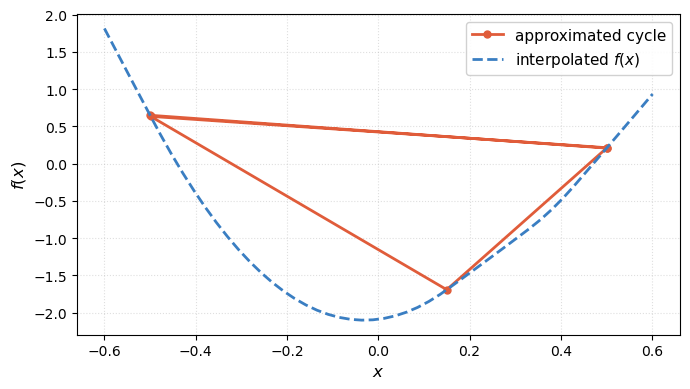

In [36]:
# Evaluation of the trajectory:
x_list_evaluated = [x.eval()[0] for x in x_list] # iterates
f_list_evaluated = [f.eval() for f in f_list] # function values

feval = func.get_interpolator()

# Create a grid of points where an interpolating function should be computed:
nb_pts_grid = 50
x_min = np.min([x_list_evaluated,x_list_evaluated])
x_max = np.max([x_list_evaluated,x_list_evaluated])
x_test = np.linspace(x_min-.1,x_max+.1,nb_pts_grid)

# Use the interpolation tools: evaluate a function using the "feval" interpolator on the grid:
fx_test = np.zeros(x_test.shape)
for i in range(len(x_test)):
    fx_test[i] = feval(np.array([x_test[i]]))
    print(f'{i + 1} / {len(x_test)} grid points computed', end='\r', flush=True)

# plot the example
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x_list_evaluated, f_list_evaluated, '-',  marker='o', ms=5, color='#e05c3a', lw=2, label='approximated cycle')
ax.plot(x_test,           fx_test,          '--',             color='#3a7ec2', lw=2, label='interpolated $f(x)$')

ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$f(x)$', fontsize=12)
ax.legend(framealpha=0.9, fontsize=11)
ax.grid(ls=':', alpha=0.4)

plt.tight_layout()
plt.show()

### 6. Going further <a class="anchor" id="sec6"></a>

While this notebook tries to cover a number of topics related to searching compact convergence certificates for first-order algorithms, there are many ways to push this further, among which:
- this theory can be used for composite optimization and operator splitting [11] (see also specialized software [12]), but also stochastic/randomized algorithms, at low additional complexification cost.
- There exists a number of related proof techniques, such as Nesterov's estimate sequences [16]. Their verification, as well as searching for such proof structures, can often be translated to *compact performance estimation problems*, similar to what we have explored here.
- The topic of potential and Lyapunov functions can be used in closed collaboration with algorithm design techniques (some of such techniques are covered in the next notebook).
- Translating Lyapunov-based proofs to closed-forms remain generally a challenge. We currently have to resort on many heuristics in order to search for simple proofs within the allowed space of proofs. Such heuristic considerations are the usual "sparse/low-rank optimization" ones [18, 19], such as the  trace or the logdet heuristics (see, e.g., [17] and the corresponding [codes](https://github.com/DanielBergThomsen/error-feedback-tight)).


---

### References

[1] Y. Drori and M. Teboulle, *Performance of first-order methods for smooth convex minimization: a novel approach*, Mathematical Programming, 2014. [arXiv:1206.3209](https://arxiv.org/abs/1206.3209)

[2] A. B. Taylor, J. M. Hendrickx and F. Glineur, *Smooth strongly convex interpolation and exact worst-case performance of first-order methods*, Mathematical Programming, 2017. [arXiv:1502.05666](https://arxiv.org/abs/1502.05666)

[3] Y. Nesterov, *A method of solving a convex programming problem with convergence rate $O(1/k^2)$*, Doklady Akademii Nauk SSSR, 1983. [English translation](https://github.com/PerformanceEstimation/Tutorial-SMAI-MODE/References/1983_Nesterov.pdf)

[4] A. Beck and M. Teboulle, *A fast iterative shrinkage-thresholding algorithm for linear inverse problems*, SIAM journal on imaging sciences, 2009. [SIAM](https://epubs.siam.org/doi/10.1137/080716542)

[5] P. Tseng, *On accelerated proximal gradient methods for convex-concave optimization*. [Author's copy](https://www.mit.edu/~dimitrib/PTseng/papers/apgm.pdf)

[6] N. Bansal and A. Gupta, *Potential-function proofs for gradient methods*, Theory of Computin, 2019. [arXiv:1712.04581](https://arxiv.org/abs/1712.04581)

[7] A. Chambolle and T. Pock, *A first-order primal-dual algorithm for convex problems with applications to imaging*, Journal of mathematical imaging and vision, 2011. [HAL:00490826](https://inria.hal.science/hal-00490826/)

[8] L. Lessard, B. Recht and A. Packard, *Analysis and design of optimization algorithms via integral quadratic constraints*, SIAM Journal on Optimization, 2016. [arXiv:1408.3595](https://arxiv.org/abs/1408.3595)

[9] A. Taylor and F. Bach, *Stochastic first-order methods: non-asymptotic and computer-aided analyses via potential functions*, Conference on Learning Theory (COLT), 2019. [arXiv:1902.00947](https://arxiv.org/abs/1902.00947)

[10] A. Taylor, B. Van Scoy and L. Lessard, *Lyapunov functions for first-order methods: Tight automated convergence guarantees*, International Conference on Machine Learning (ICML), 2018. [arXiv:1803.06073](https://arxiv.org/abs/1803.06073)

[11] M. Upadhyaya, S. Banert, A. Taylor and P. Giselsson, *Automated tight Lyapunov analysis for first-order methods*, Mathematical Programming, 2025. [arXiv:2302.06713](https://arxiv.org/abs/2302.06713)

[12] M. Upadhyaya, S. Das Gupta, A. Taylor, S. Banert and P. Giselsson, *The AutoLyap software suite for computer-assisted Lyapunov analyses of first-order methods*, 2025. [arXiv:2506.24076](https://arxiv.org/abs/2506.24076)

[13] B. Goujaud, A. Dieuleveut and A. Taylor, *Counter-examples in first-order optimization: a constructive approach*, IEEE Control Systems Letters, 2023.[arXiv:2303.10503](https://arxiv.org/abs/2303.10503)
 
[14] B. Goujaud, A. Taylor and A. Dieuleveut, *Provable non-accelerations of the heavy-ball method*, Mathematical Programming, 2025. [arXiv:2307.11291](https://arxiv.org/abs/2307.11291)

[15] B. Polyak, *Introduction to optimization*, Optimization Software, 1987. [English translation](https://github.com/PerformanceEstimation/Tutorial-SMAI-MODE/References/1987_Polyak.pdf)

[16] Y. Nesterov, *Introductory lectures on convex optimization: A basic course*, Springer Science & Business Media, 2003. [Github](https://hengshuaiyao.github.io/papers/nesterov03.pdf)

[17] D. Berg Thomsen, A. Taylor, A. Dieuleveut, *Tight analyses of first-order methods with error feedback*, Advances in Neural Information Processing Systems 38 (NeurIPS), 2025. [arXiv:2506.05271](https://arxiv.org/abs/2506.05271)

[18] M. Fazel, H. Hindi and S. Boyd, *A rank minimization heuristic with application to minimum order system approximation*. American control conference (ACC), 2001.  [Author's copy](https://faculty.washington.edu/mfazel/nucnorm_acc_final.pdf)

[19] M. Fazel, H. Hindi and S. Boyd, *Log-det heuristic for matrix rank minimization with applications to Hankel and Euclidean distance matrices*, American Control Conference (ACC), 2003. [Author's copy](https://web.stanford.edu/~boyd/papers/pdf/rank_min_heur_hankel.pdf)

[20] B. Van Scoy, R.A. Freeman and K.M. Lynch, *The Fastest Known Globally Convergent First-Order Method for Minimizing Strongly Convex Functions*, IEEE Control Systems Letters, 2017. [Author's copy](https://liberzon.csl.illinois.edu/teaching/freeman-fast-gradient.pdf)